In [ ]:
!pip install -q imbalanced-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import OrdinalEncoder
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

# Global plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
COLORS   = {"Yes": "#E05C5C", "No": "#4A90D9"}   # red = attrited, blue = stayed
ACCENT   = "#4A90D9"
SOFT_RED = "#E05C5C"

print("✅  Libraries loaded")

✅  Libraries loaded


# [CELL 1-1]  Upload & Read

In [ ]:
from google.colab import files
import io

uploaded = files.upload()                         # ← upload CSV here
filename  = list(uploaded.keys())[0]
df_raw    = pd.read_csv(io.BytesIO(uploaded[filename]))
df        = df_raw.copy()                         # working copy

print(f"✅  Loaded  →  {df.shape[0]:,} rows × {df.shape[1]} columns")

print("─── Shape ───────────────────────────────────")
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")

print("\n─── Data Types ──────────────────────────────")
print(df.dtypes.to_string())

print("\n─── First 5 Rows ────────────────────────────")
df.head()

df.describe(include="all").T



Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv
✅  Loaded  →  1,470 rows × 35 columns
─── Shape ───────────────────────────────────
  Rows    : 1,470
  Columns : 35

─── Data Types ──────────────────────────────
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18         

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1470,2,No,1233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,1470.0,NaN,NaN,NaN,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0


In [ ]:
print("╔══ 2.1  MISSING VALUES ══════════════════════╗")

miss_count = df.isnull().sum()
miss_pct   = (miss_count / len(df) * 100).round(2)
miss_df    = pd.DataFrame({"Missing Count": miss_count, "Missing %": miss_pct})
miss_df    = miss_df[miss_df["Missing Count"] > 0]

if miss_df.empty:
    print("  ✅  No missing values found in any column.")
else:
    # Bar chart of missing %
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(miss_df.index, miss_df["Missing %"], color=SOFT_RED, edgecolor="white")
    ax.set_xlabel("Missing %")
    ax.set_title("Missing Values by Column")
    for i, v in enumerate(miss_df["Missing %"]):
        ax.text(v + 0.2, i, f"{v}%", va="center")
    plt.tight_layout()
    plt.show()
    print(miss_df)


╔══ 2.1  MISSING VALUES ══════════════════════╗
  ✅  No missing values found in any column.


In [ ]:
print("╔══ 2.2  DUPLICATES ══════════════════════════╗")

dup_count = df.duplicated().sum()
print(f"  Duplicate rows : {dup_count}")

if dup_count > 0:
    print("\n  Duplicated rows preview:")
    print(df[df.duplicated(keep=False)].head())
else:
    print("  ✅  No duplicate rows.")


╔══ 2.2  DUPLICATES ══════════════════════════╗
  Duplicate rows : 0
  ✅  No duplicate rows.


╔══ 2.3  OUTLIER DETECTION ═══════════════════╗
                  Column      Q1       Q3  Lower Fence  Upper Fence  Outlier Count  Outlier %
   TrainingTimesLastYear    2.00     3.00         0.50         4.50            238      16.19
       PerformanceRating    3.00     3.00         3.00         3.00            226      15.37
           MonthlyIncome 2911.00  8379.00     -5291.00     16581.00            114       7.76
 YearsSinceLastPromotion    0.00     3.00        -4.50         7.50            107       7.28
          YearsAtCompany    3.00     9.00        -6.00        18.00            104       7.07
        StockOptionLevel    0.00     1.00        -1.50         2.50             85       5.78
       TotalWorkingYears    6.00    15.00        -7.50        28.50             63       4.29
      NumCompaniesWorked    1.00     4.00        -3.50         8.50             52       3.54
      YearsInCurrentRole    2.00     7.00        -5.50        14.50             21       1.43
    YearsWit

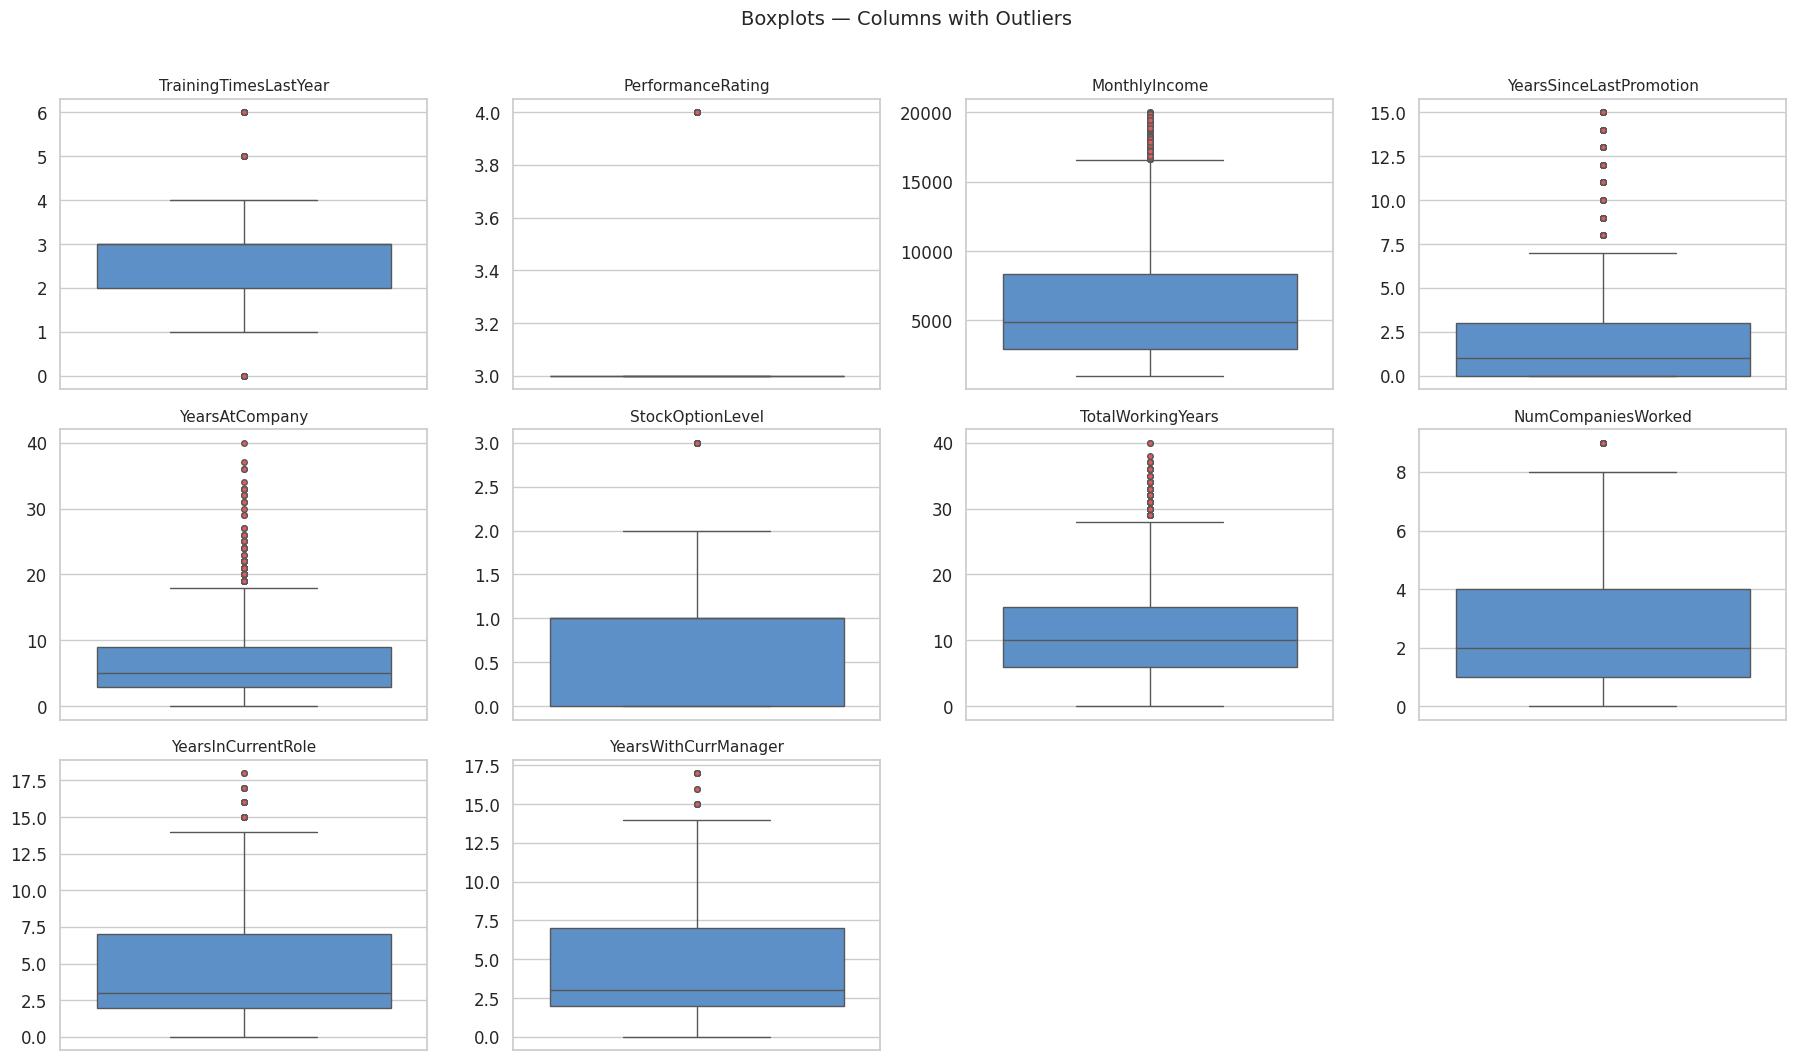

In [ ]:
print("╔══ 2.3  OUTLIER DETECTION ═══════════════════╗")

num_cols = df.select_dtypes(include="number").columns.tolist()

# ── IQR summary table ─────────────────────────────────────────
outlier_rows = []
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out  = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_rows.append({
        "Column"        : col,
        "Q1"            : round(Q1, 2),
        "Q3"            : round(Q3, 2),
        "Lower Fence"   : round(lo, 2),
        "Upper Fence"   : round(hi, 2),
        "Outlier Count" : n_out,
        "Outlier %"     : round(n_out / len(df) * 100, 2),
    })

outlier_df = (pd.DataFrame(outlier_rows)
              .sort_values("Outlier Count", ascending=False)
              .reset_index(drop=True))
print(outlier_df.to_string(index=False))

# ── Boxplots for columns that have outliers ────────────────────
has_outlier = outlier_df[outlier_df["Outlier Count"] > 0]["Column"].tolist()

if has_outlier:
    ncols_p = 4
    nrows_p = (len(has_outlier) + ncols_p - 1) // ncols_p
    fig, axes = plt.subplots(nrows_p, ncols_p,
                             figsize=(18, nrows_p * 3.5))
    axes = axes.flatten()
    for i, col in enumerate(has_outlier):
        sns.boxplot(y=df[col], ax=axes[i], color=ACCENT,
                    flierprops={"marker": "o", "markersize": 4,
                                "markerfacecolor": SOFT_RED})
        axes[i].set_title(col, fontsize=11)
        axes[i].set_ylabel("")
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Boxplots — Columns with Outliers", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()


In [ ]:
print("╔══ 2.4  LOGIC CHECKS ════════════════════════╗")

logic_checks = {
    "TotalWorkingYears < YearsAtCompany"       : df["TotalWorkingYears"] < df["YearsAtCompany"],
    "YearsAtCompany < YearsInCurrentRole"      : df["YearsAtCompany"]    < df["YearsInCurrentRole"],
    "YearsAtCompany < YearsWithCurrManager"    : df["YearsAtCompany"]    < df["YearsWithCurrManager"],
    "YearsAtCompany < YearsSinceLastPromotion" : df["YearsAtCompany"]    < df["YearsSinceLastPromotion"],
    "Age < 18"                                 : df["Age"] < 18,
    "MonthlyIncome <= 0"                       : df["MonthlyIncome"] <= 0,
}

for label, mask in logic_checks.items():
    count  = mask.sum()
    status = "⚠️ " if count > 0 else "✅"
    print(f"  {status}  {label:<50} → {count:>4} row(s)")

╔══ 2.4  LOGIC CHECKS ════════════════════════╗
  ✅  TotalWorkingYears < YearsAtCompany                 →    0 row(s)
  ✅  YearsAtCompany < YearsInCurrentRole                →    0 row(s)
  ✅  YearsAtCompany < YearsWithCurrManager              →    0 row(s)
  ✅  YearsAtCompany < YearsSinceLastPromotion           →    0 row(s)
  ✅  Age < 18                                           →    0 row(s)
  ✅  MonthlyIncome <= 0                                 →    0 row(s)


In [ ]:
print("╔══ 2.5  CONSTANT COLUMNS ════════════════════╗")

constant_cols = [c for c in df.columns if df[c].nunique() == 1]
if constant_cols:
    for c in constant_cols:
        print(f"  ⚠️  {c}  →  always = {df[c].iloc[0]!r}")
else:
    print("  ✅  No constant columns found.")


╔══ 2.5  CONSTANT COLUMNS ════════════════════╗
  ⚠️  EmployeeCount  →  always = np.int64(1)
  ⚠️  Over18  →  always = 'Y'
  ⚠️  StandardHours  →  always = np.int64(80)


╔══ 2.6  TARGET VARIABLE — Attrition ═════════╗
Attrition
No     1233
Yes     237
Attrition
No     83.9 %
Yes    16.1 %


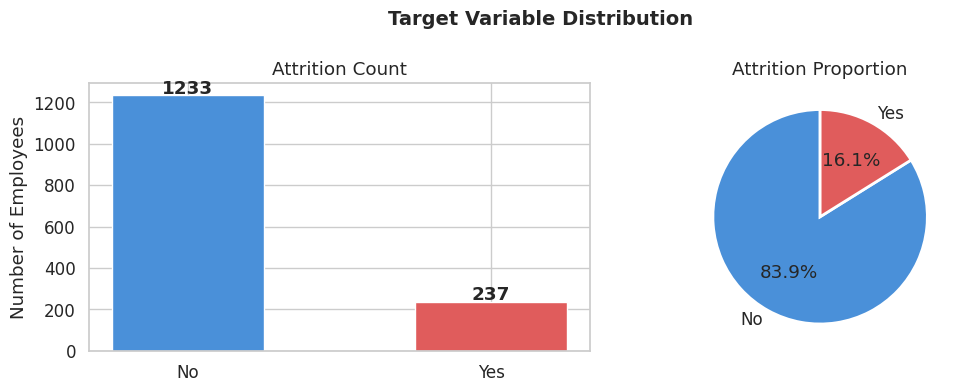

In [ ]:
print("╔══ 2.6  TARGET VARIABLE — Attrition ═════════╗")

att_counts = df["Attrition"].value_counts()
att_pct    = df["Attrition"].value_counts(normalize=True).mul(100).round(1)
print(att_counts.to_string())
print((att_pct.astype(str) + " %").to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Count bar
axes[0].bar(att_counts.index, att_counts.values,
            color=[COLORS[k] for k in att_counts.index],
            edgecolor="white", width=0.5)
for i, (k, v) in enumerate(att_counts.items()):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")
axes[0].set_title("Attrition Count")
axes[0].set_ylabel("Number of Employees")

# Pie
axes[1].pie(att_counts.values,
            labels=att_counts.index,
            colors=[COLORS[k] for k in att_counts.index],
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Attrition Proportion")

plt.suptitle("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
print("╔══ 3.1  DROP USELESS COLUMNS ════════════════╗")

# EmployeeCount  → constant = 1
# Over18         → constant = 'Y'
# StandardHours  → constant = 80
# EmployeeNumber → arbitrary row ID, not a feature
drop_zero_info = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]
df.drop(columns=drop_zero_info, inplace=True)

print(f"  Dropped : {drop_zero_info}")
print(f"  Shape   : {df.shape}")

╔══ 3.1  DROP USELESS COLUMNS ════════════════╗
  Dropped : ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
  Shape   : (1470, 31)


In [ ]:
print("╔══ 3.2  REMOVE DUPLICATES ═══════════════════╗")

before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
removed = before - len(df)
print(f"  Removed {removed} duplicate row(s).")
print(f"  Shape : {df.shape}")

╔══ 3.2  REMOVE DUPLICATES ═══════════════════╗
  Removed 0 duplicate row(s).
  Shape : (1470, 31)


In [ ]:
print("╔══ 3.3  CAP OUTLIERS (Winsorisation) ════════╗")

# Rate/salary columns skew naturally in real payroll data → skip capping
skip_cap  = {"MonthlyIncome", "DailyRate", "HourlyRate", "MonthlyRate"}
num_now   = df.select_dtypes(include="number").columns.tolist()
capped_log = []

for col in num_now:
    if col in skip_cap:
        continue
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_pre  = ((df[col] < lo) | (df[col] > hi)).sum()
    if n_pre > 0:
        df[col] = df[col].clip(lower=lo, upper=hi)
        capped_log.append(f"  ✂️  {col:<35} → {n_pre} values capped")

print("\n".join(capped_log) if capped_log else "  ✅  No outliers required capping.")
print(f"\n  Shape after capping : {df.shape}")


╔══ 3.3  CAP OUTLIERS (Winsorisation) ════════╗
  ✂️  NumCompaniesWorked                  → 52 values capped
  ✂️  PerformanceRating                   → 226 values capped
  ✂️  StockOptionLevel                    → 85 values capped
  ✂️  TotalWorkingYears                   → 63 values capped
  ✂️  TrainingTimesLastYear               → 238 values capped
  ✂️  YearsAtCompany                      → 104 values capped
  ✂️  YearsInCurrentRole                  → 21 values capped
  ✂️  YearsSinceLastPromotion             → 107 values capped
  ✂️  YearsWithCurrManager                → 14 values capped

  Shape after capping : (1470, 31)


In [ ]:
print("╔══ 3.4  CLEANED DATA SUMMARY ════════════════╗")
print(f"  Shape          : {df.shape}")
print(f"  Missing values : {df.isnull().sum().sum()}")
print(f"  Duplicates     : {df.duplicated().sum()}")
print("\n  Column dtypes:")
print(df.dtypes.to_string())

╔══ 3.4  CLEANED DATA SUMMARY ════════════════╗
  Shape          : (1470, 31)
  Missing values : 0
  Duplicates     : 0

  Column dtypes:
Age                           int64
Attrition                    object
BusinessTravel               object
DailyRate                     int64
Department                   object
DistanceFromHome              int64
Education                     int64
EducationField               object
EnvironmentSatisfaction       int64
Gender                       object
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                      object
JobSatisfaction               int64
MaritalStatus                object
MonthlyIncome                 int64
MonthlyRate                   int64
NumCompaniesWorked          float64
OverTime                     object
PercentSalaryHike             int64
PerformanceRating             int64
RelationshipSatisfaction      int64
StockOptionLevel            float6

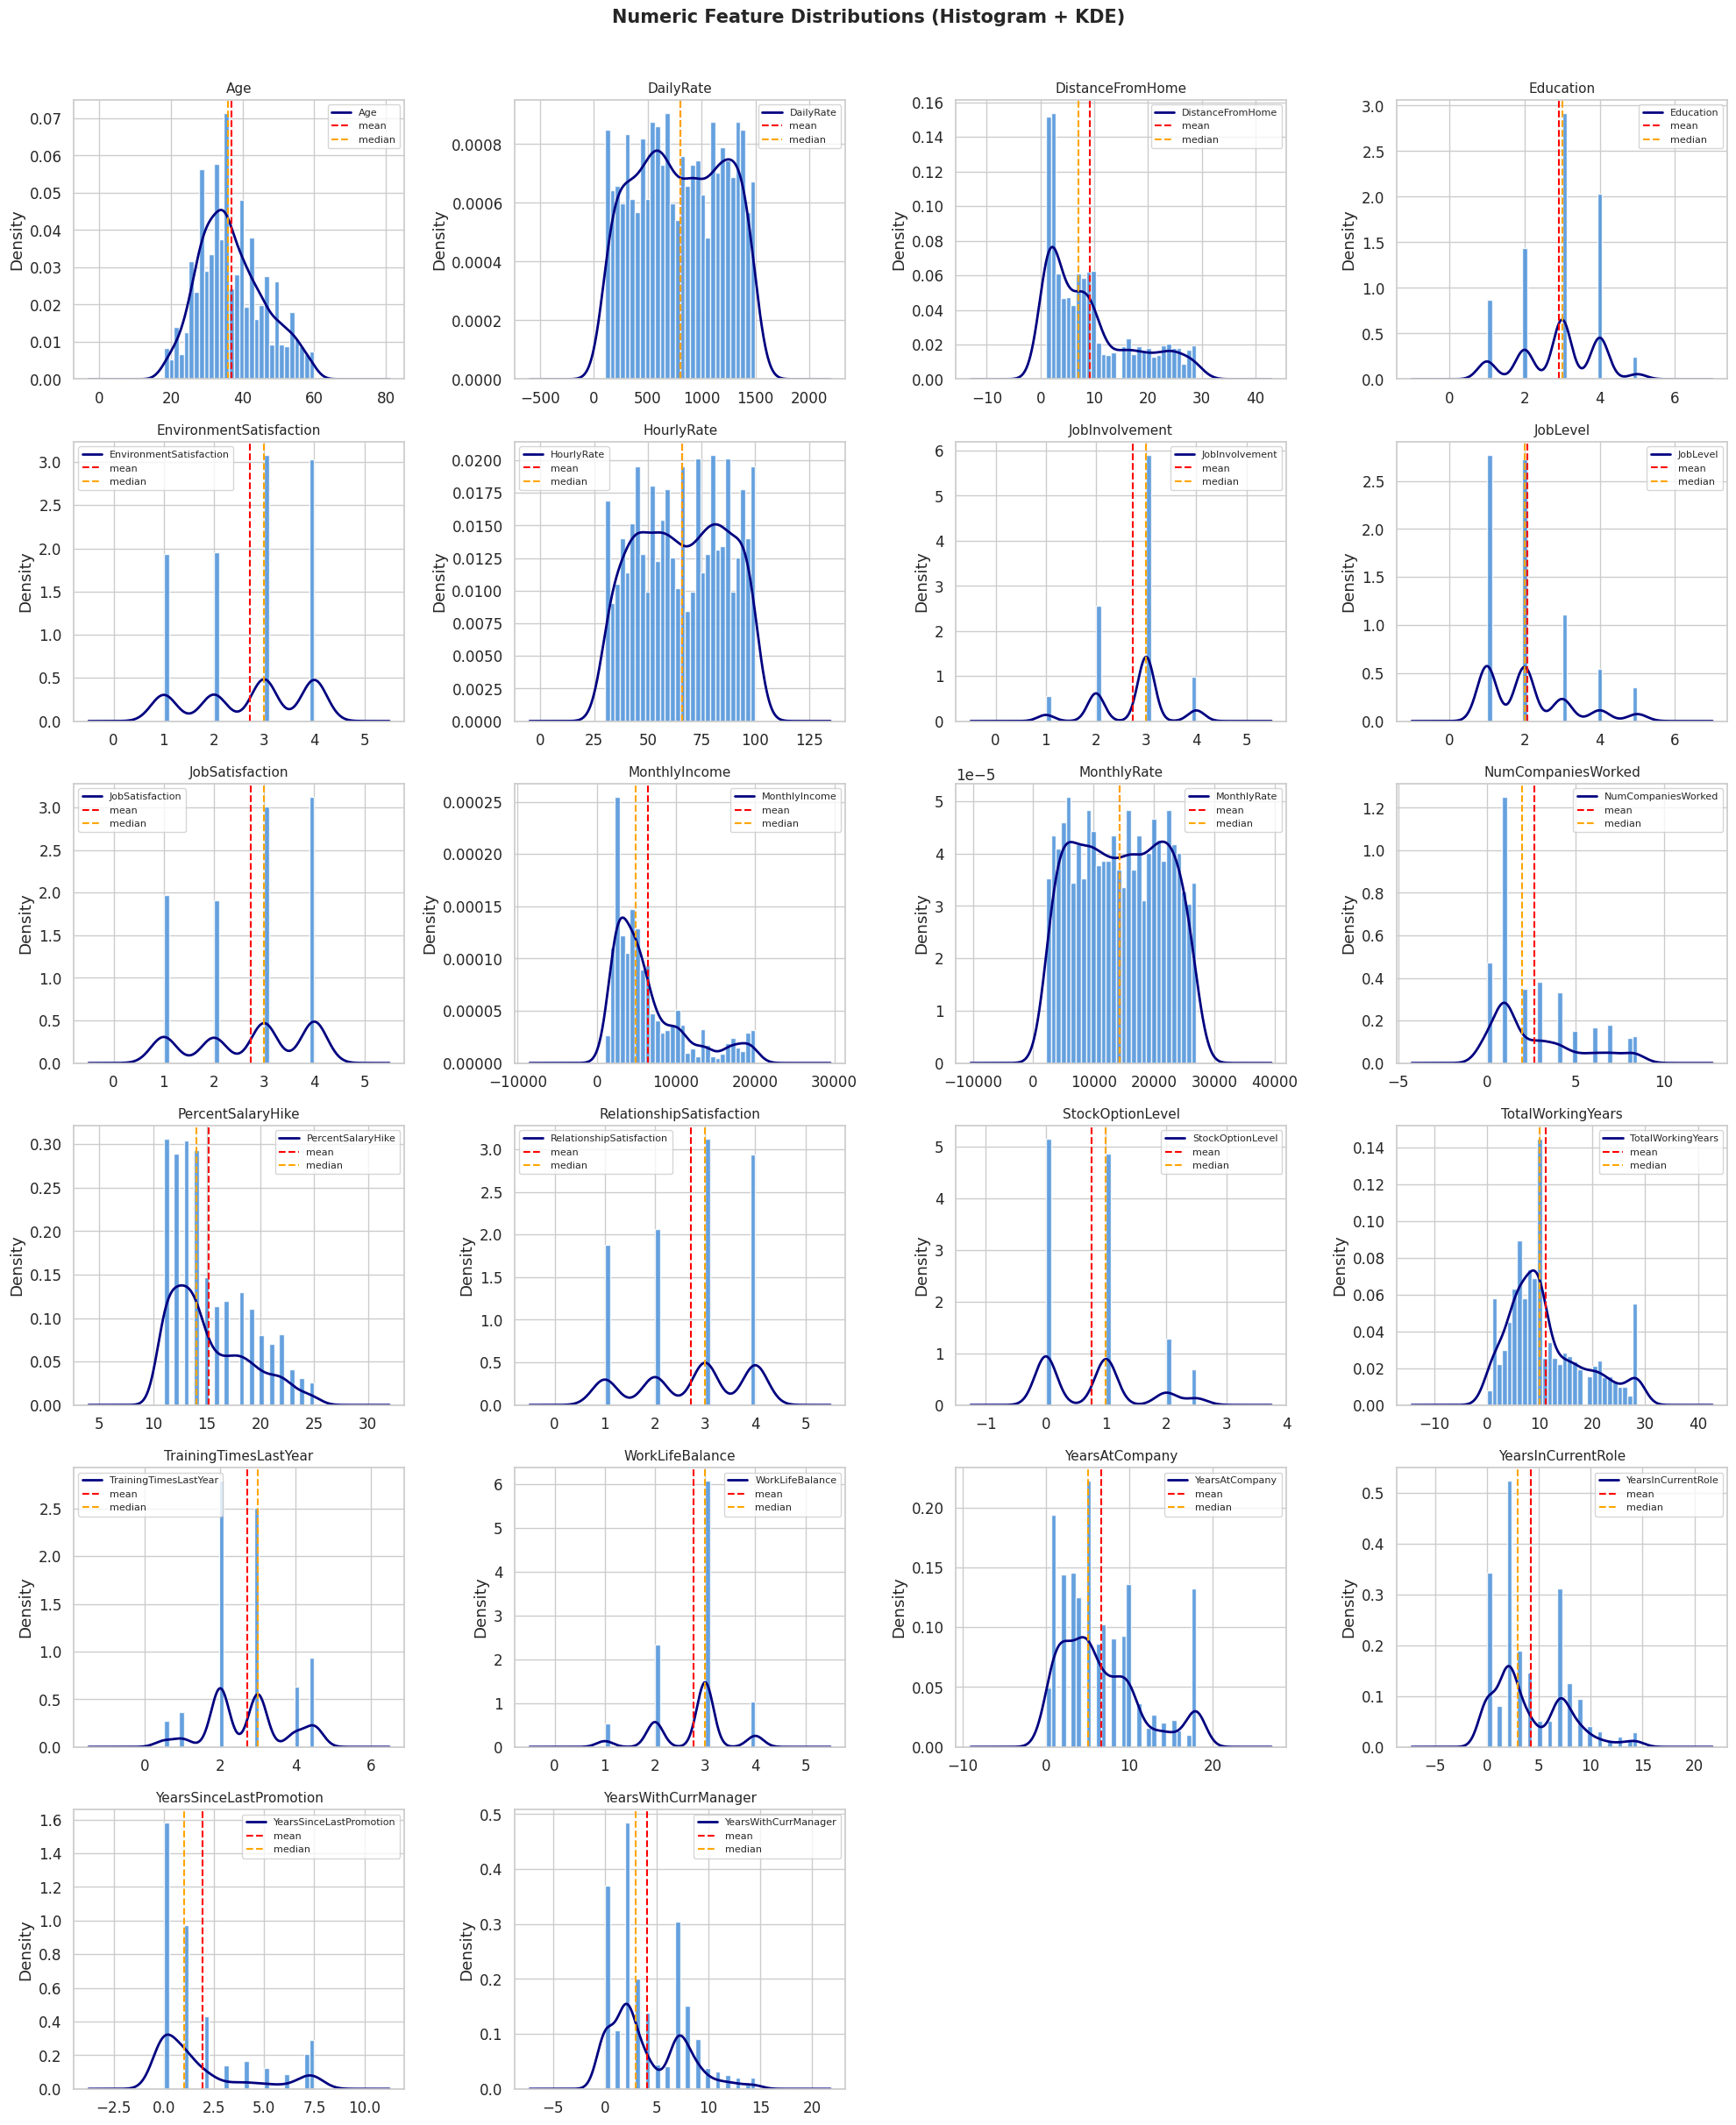

In [ ]:
# ─────────────────────────────────────────────────────────────────
# [CELL 4-1]  Numeric — Histograms with KDE
# ─────────────────────────────────────────────────────────────────
num_cols = df.select_dtypes(include="number").columns.tolist()

# Exclude 'PerformanceRating' due to its low cardinality (only 2 unique values) which causes LinAlgError in KDE.
num_cols_for_kde = [col for col in num_cols if col != "PerformanceRating"]

ncols_p  = 4
nrows_p  = (len(num_cols_for_kde) + ncols_p - 1) // ncols_p

fig, axes = plt.subplots(nrows_p, ncols_p, figsize=(20, nrows_p * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols_for_kde):
    axes[i].hist(df[col], bins=30, color=ACCENT,
                 edgecolor="white", alpha=0.85, density=True)
    df[col].plot.kde(ax=axes[i], color="navy", linewidth=2)
    axes[i].axvline(df[col].mean(),   color="red",    ls="--", lw=1.5, label="mean")
    axes[i].axvline(df[col].median(), color="orange", ls="--", lw=1.5, label="median")
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel("")
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Feature Distributions (Histogram + KDE)",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

                 Feature  Skewness      Flag
           MonthlyIncome     1.370  ⚠️  High
 YearsSinceLastPromotion     1.263  ⚠️  High
                JobLevel     1.025  ⚠️  High
      NumCompaniesWorked     0.972  Moderate
        DistanceFromHome     0.958  Moderate
          YearsAtCompany     0.901  Moderate
       TotalWorkingYears     0.856  Moderate
       PercentSalaryHike     0.821  Moderate
      YearsInCurrentRole     0.804  Moderate
    YearsWithCurrManager     0.741  Moderate
        StockOptionLevel     0.665  Moderate
         WorkLifeBalance    -0.552  Moderate
          JobInvolvement    -0.498 ✅  Normal
                     Age     0.413 ✅  Normal
         JobSatisfaction    -0.330 ✅  Normal
 EnvironmentSatisfaction    -0.322 ✅  Normal
RelationshipSatisfaction    -0.303 ✅  Normal
               Education    -0.290 ✅  Normal
   TrainingTimesLastYear     0.118 ✅  Normal
              HourlyRate    -0.032 ✅  Normal
             MonthlyRate     0.019 ✅  Normal
          

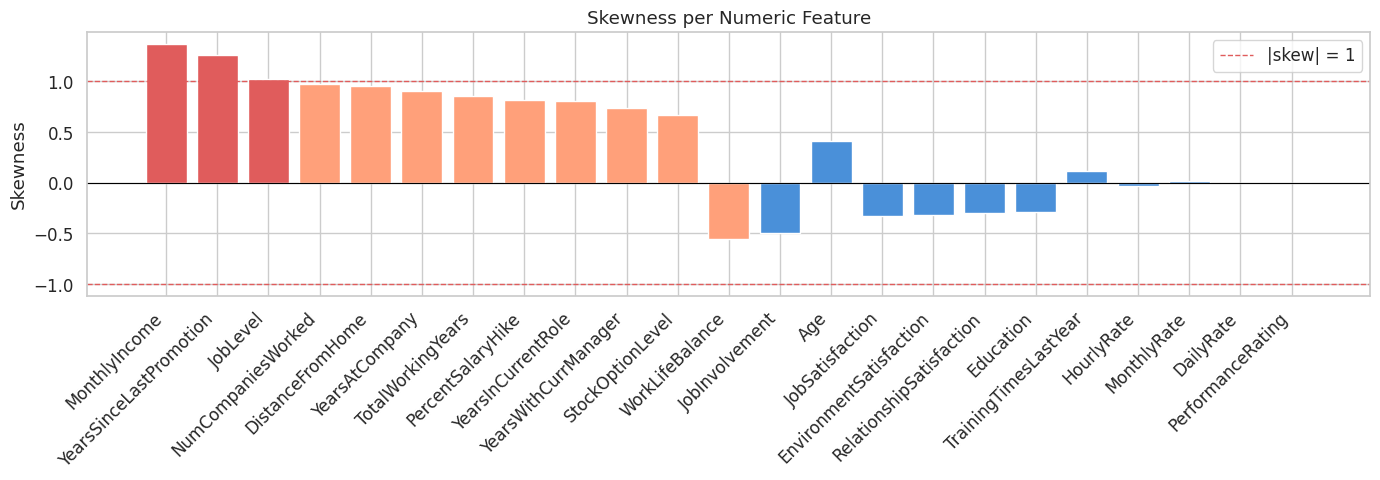

In [ ]:
# ─────────────────────────────────────────────────────────────────
# [CELL 4-2]  Numeric — Skewness Table
# ─────────────────────────────────────────────────────────────────
skew_df = (df[num_cols].skew()
           .sort_values(key=abs, ascending=False)
           .rename("Skewness")
           .reset_index())
skew_df.columns = ["Feature", "Skewness"]
skew_df["Skewness"] = skew_df["Skewness"].round(3)
skew_df["Flag"] = skew_df["Skewness"].apply(
    lambda x: "⚠️  High"    if abs(x) > 1
         else "Moderate" if abs(x) > 0.5
         else "✅  Normal"
)
print(skew_df.to_string(index=False))

# Bar chart of skewness
fig, ax = plt.subplots(figsize=(14, 5))
bar_colors = [SOFT_RED if abs(s) > 1 else "#FFA07A" if abs(s) > 0.5
              else ACCENT for s in skew_df["Skewness"]]
ax.bar(skew_df["Feature"], skew_df["Skewness"], color=bar_colors, edgecolor="white")
ax.axhline(0,  color="black", linewidth=0.8)
ax.axhline( 1, color=SOFT_RED, ls="--", lw=1, label="|skew| = 1")
ax.axhline(-1, color=SOFT_RED, ls="--", lw=1)
ax.set_xticklabels(skew_df["Feature"], rotation=45, ha="right")
ax.set_ylabel("Skewness")
ax.set_title("Skewness per Numeric Feature")
ax.legend()
plt.tight_layout()
plt.show()

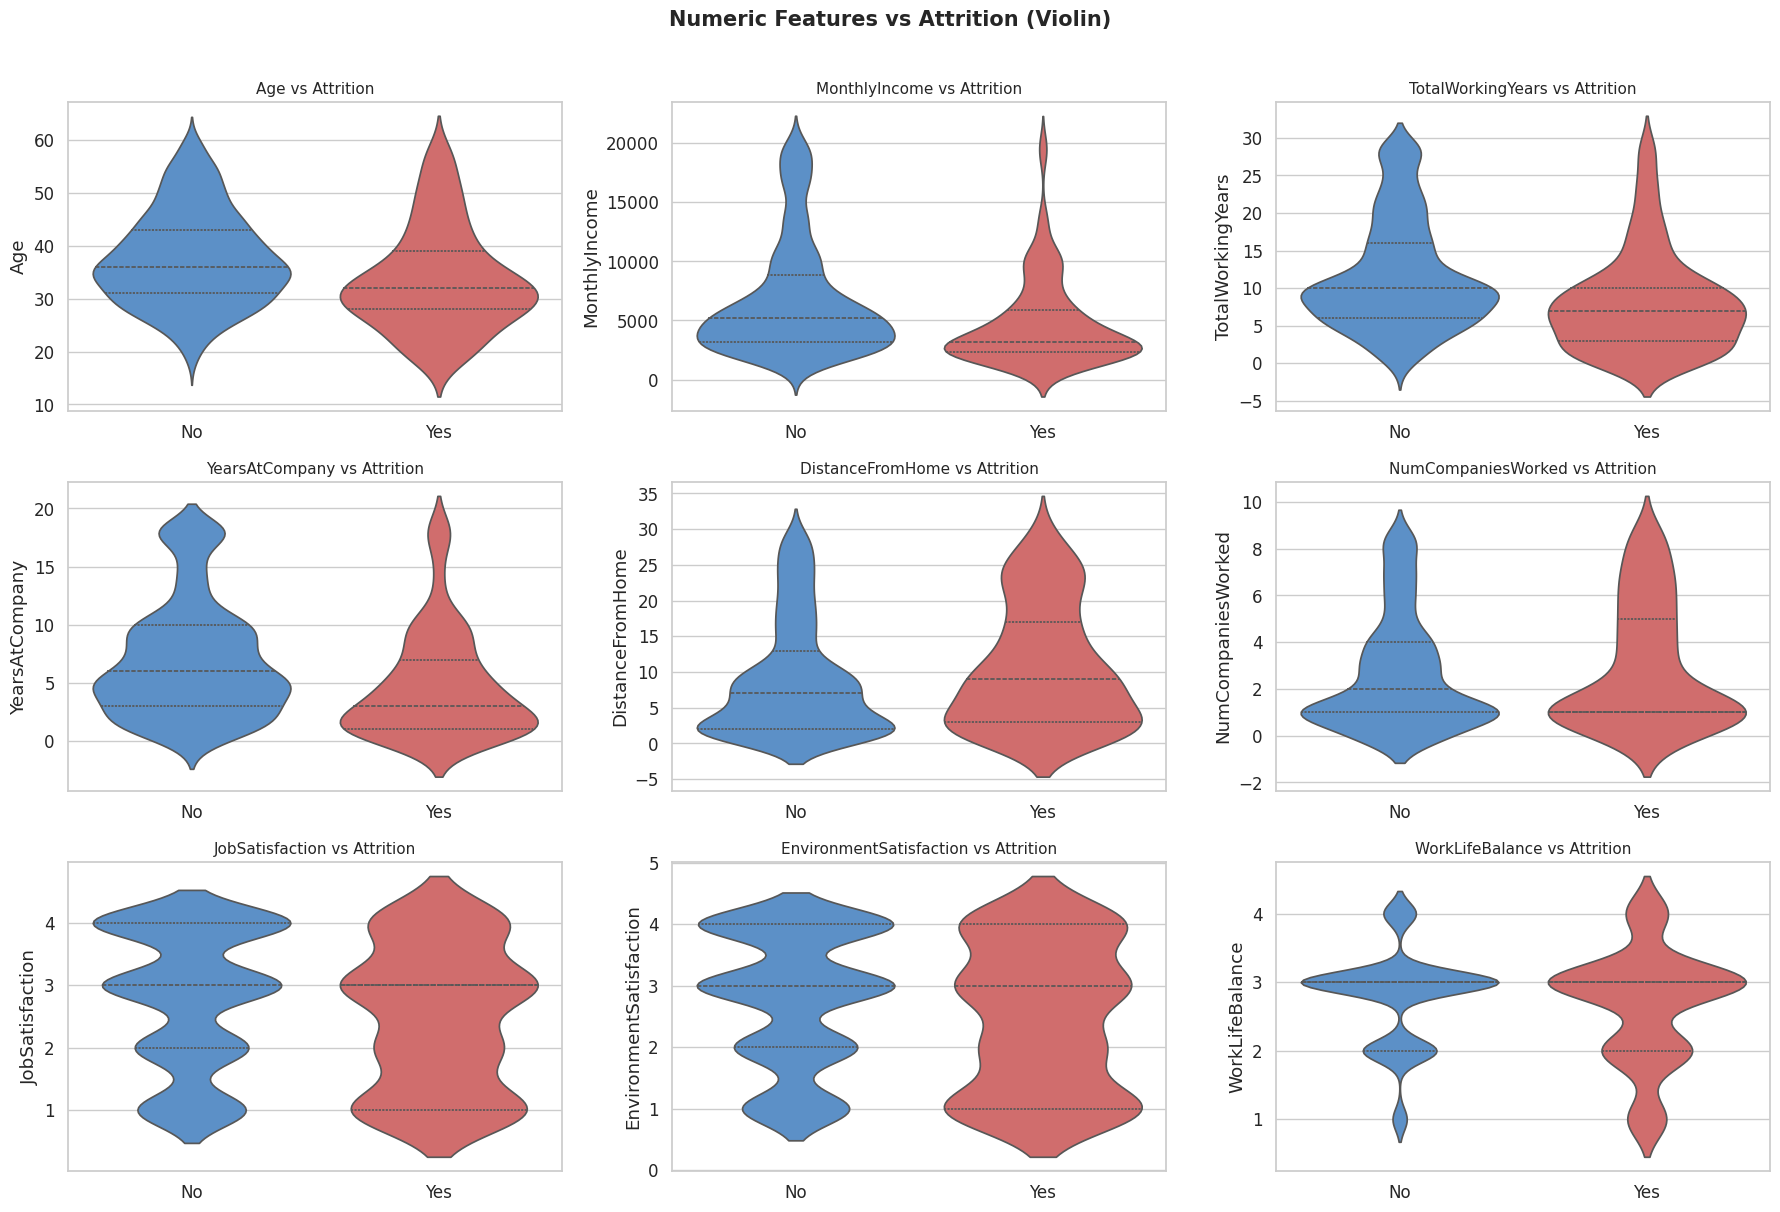

In [ ]:
# ─────────────────────────────────────────────────────────────────
# [CELL 4-3]  Numeric vs Target — Violin Plots
# ─────────────────────────────────────────────────────────────────
key_num = ["Age", "MonthlyIncome", "TotalWorkingYears",
           "YearsAtCompany", "DistanceFromHome", "NumCompaniesWorked",
           "JobSatisfaction", "EnvironmentSatisfaction", "WorkLifeBalance"]

ncols_p = 3
nrows_p = (len(key_num) + ncols_p - 1) // ncols_p

fig, axes = plt.subplots(nrows_p, ncols_p, figsize=(18, nrows_p * 4))
axes = axes.flatten()

for i, col in enumerate(key_num):
    sns.violinplot(data=df, x="Attrition", y=col,
                   order=["No", "Yes"],
                   palette={"No": ACCENT, "Yes": SOFT_RED},
                   inner="quartile", ax=axes[i])
    axes[i].set_title(f"{col} vs Attrition", fontsize=11)
    axes[i].set_xlabel("")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Features vs Attrition (Violin)", fontsize=15,
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

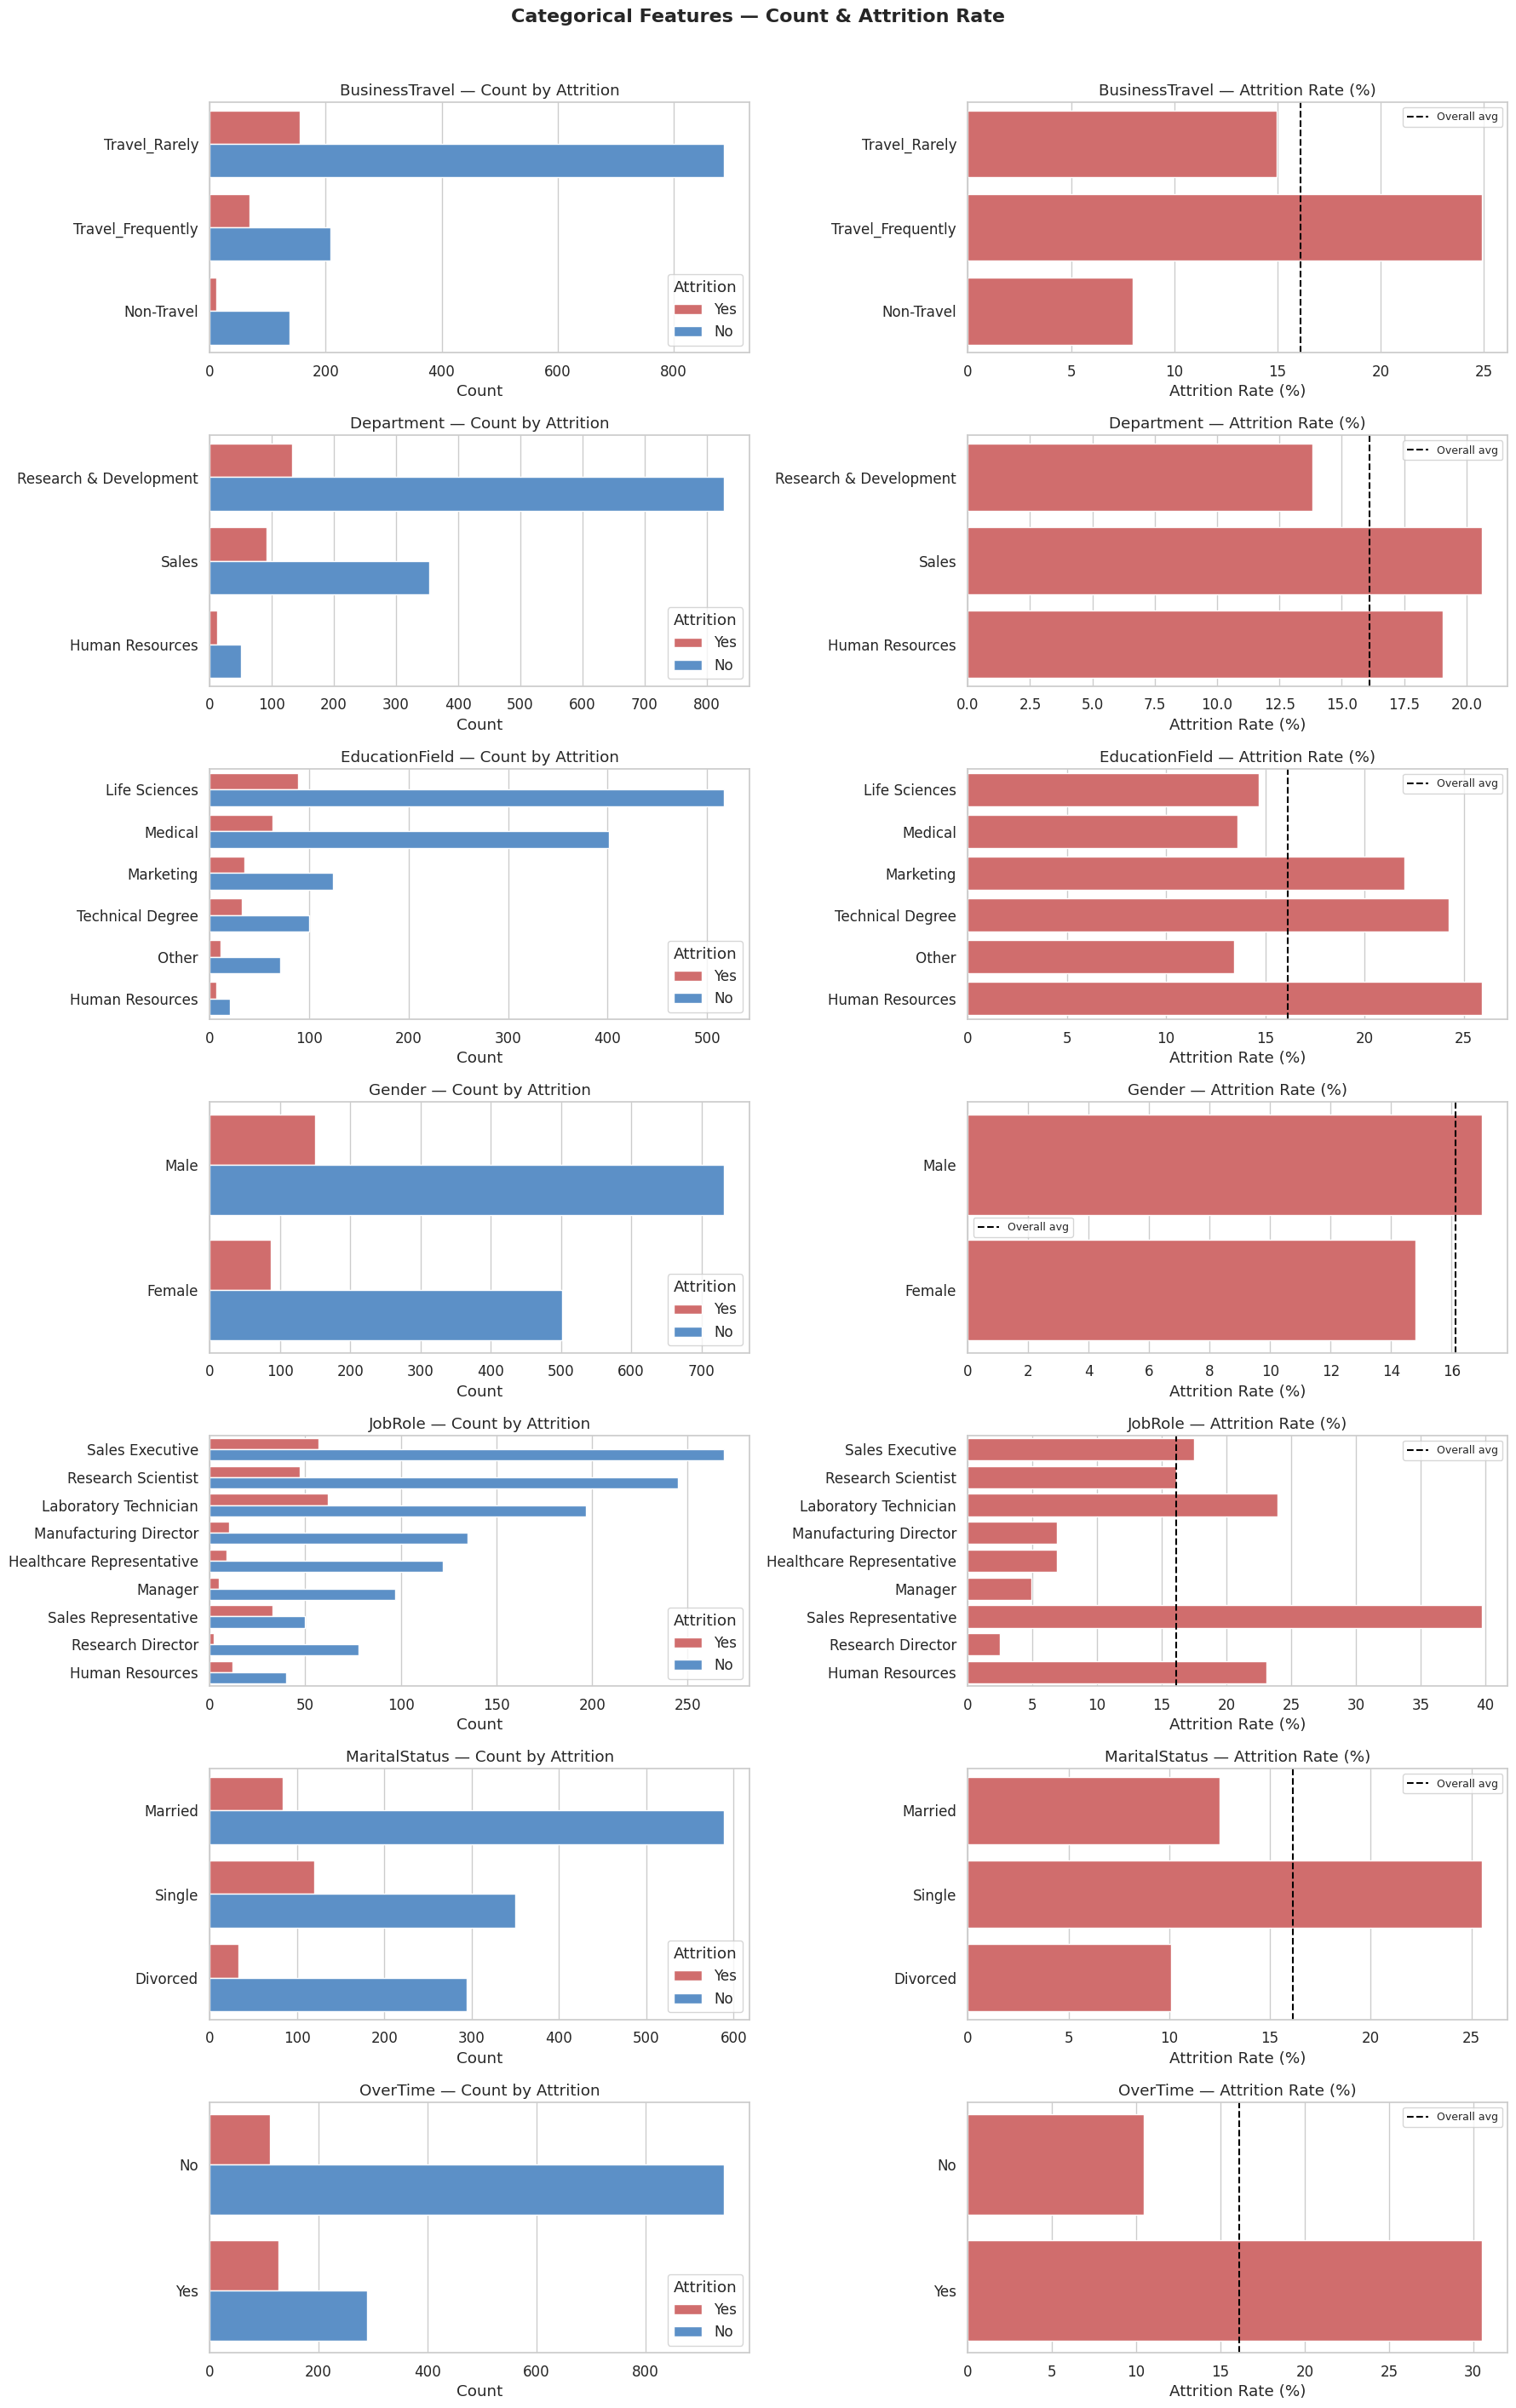

In [ ]:
# ─────────────────────────────────────────────────────────────────
# [CELL 4-4]  Categorical — Count + Attrition Rate
# ─────────────────────────────────────────────────────────────────
cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_plot = [c for c in cat_cols if c != "Attrition"]

fig, axes = plt.subplots(len(cat_plot), 2,
                         figsize=(18, len(cat_plot) * 4))

for i, col in enumerate(cat_plot):
    order = df[col].value_counts().index.tolist()

    # Left  → count bar, stacked by Attrition
    sns.countplot(data=df, y=col, hue="Attrition",
                  order=order,
                  palette={"No": ACCENT, "Yes": SOFT_RED},
                  ax=axes[i][0])
    axes[i][0].set_title(f"{col} — Count by Attrition")
    axes[i][0].set_xlabel("Count")
    axes[i][0].set_ylabel("")
    axes[i][0].legend(title="Attrition")

    # Right → attrition RATE per category
    rate = (df.groupby(col)["Attrition"]
              .apply(lambda x: (x == "Yes").mean() * 100)
              .reindex(order)
              .reset_index())
    rate.columns = [col, "Attrition Rate (%)"]
    sns.barplot(data=rate, y=col, x="Attrition Rate (%)",
                order=order, color=SOFT_RED, ax=axes[i][1])
    axes[i][1].set_title(f"{col} — Attrition Rate (%)")
    axes[i][1].set_xlabel("Attrition Rate (%)")
    axes[i][1].set_ylabel("")
    axes[i][1].axvline(
        (df["Attrition"] == "Yes").mean() * 100,
        color="black", ls="--", lw=1.5, label="Overall avg"
    )
    axes[i][1].legend(fontsize=9)

plt.suptitle("Categorical Features — Count & Attrition Rate",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


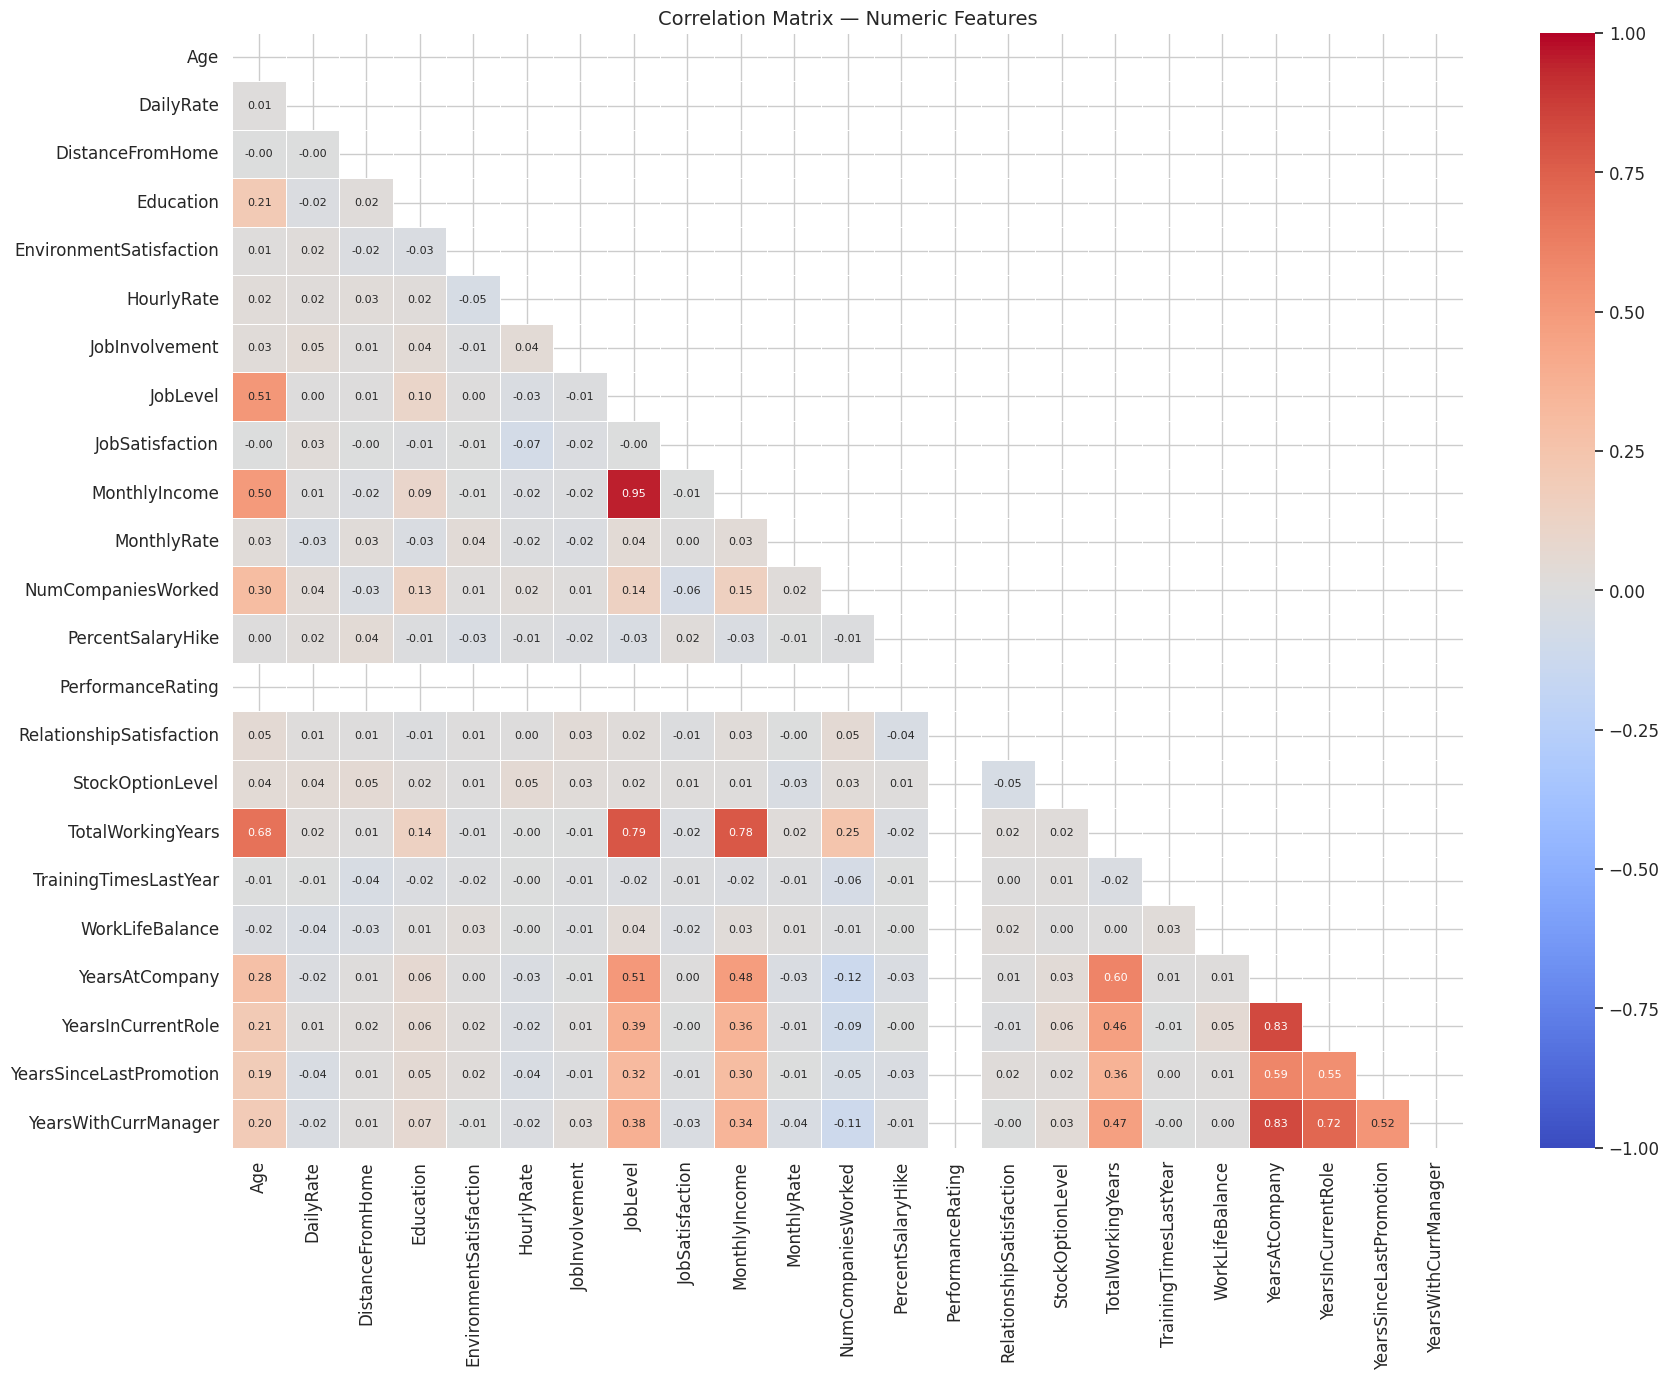


  Highly correlated pairs (|r| > 0.75):
    JobLevel  ↔  MonthlyIncome  →  r = 0.95
    JobLevel  ↔  TotalWorkingYears  →  r = 0.787
    MonthlyIncome  ↔  TotalWorkingYears  →  r = 0.775
    YearsAtCompany  ↔  YearsInCurrentRole  →  r = 0.83
    YearsAtCompany  ↔  YearsWithCurrManager  →  r = 0.834


In [ ]:
# ─────────────────────────────────────────────────────────────────
# [CELL 4-5]  Correlation Heatmap
# ─────────────────────────────────────────────────────────────────
num_cols = df.select_dtypes(include="number").columns.tolist()
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.4,
            vmin=-1, vmax=1, ax=ax,
            annot_kws={"size": 8})
ax.set_title("Correlation Matrix — Numeric Features", fontsize=14)
plt.tight_layout()
plt.show()

# High-correlation pairs
print("\n  Highly correlated pairs (|r| > 0.75):")
high_pairs = [(corr.columns[i], corr.columns[j], round(corr.iloc[i, j], 3))
              for i in range(len(corr)) for j in range(i + 1, len(corr))
              if abs(corr.iloc[i, j]) > 0.75]
for a, b, r in high_pairs:
    print(f"    {a}  ↔  {b}  →  r = {r}")

╔══ 5.1  DROP UNSUITABLE FEATURES ════════════╗
  ✂️  MonthlyRate            → high corr with MonthlyIncome, less interpretable
  ✂️  DailyRate              → high corr with MonthlyIncome, less interpretable
  ✂️  HourlyRate             → high corr with MonthlyIncome, less interpretable
  ✂️  PerformanceRating      → only 2 unique values (3 & 4) — near-zero variance

  Shape after drop : (1470, 27)
╔══ 5.2  FEATURE CREATION ════════════════════╗
  Created : ['TenureRatio', 'IncomePerAge', 'PromotionLag']

       TenureRatio  IncomePerAge  PromotionLag
count     1470.000      1470.000      1470.000
mean         0.571       170.943         0.180
std          0.274       101.848         0.773
min          0.000        36.030         0.000
25%          0.370        93.212         0.000
50%          0.610       140.970         0.000
75%          0.818       223.462         0.000
max          0.947       556.000         7.000


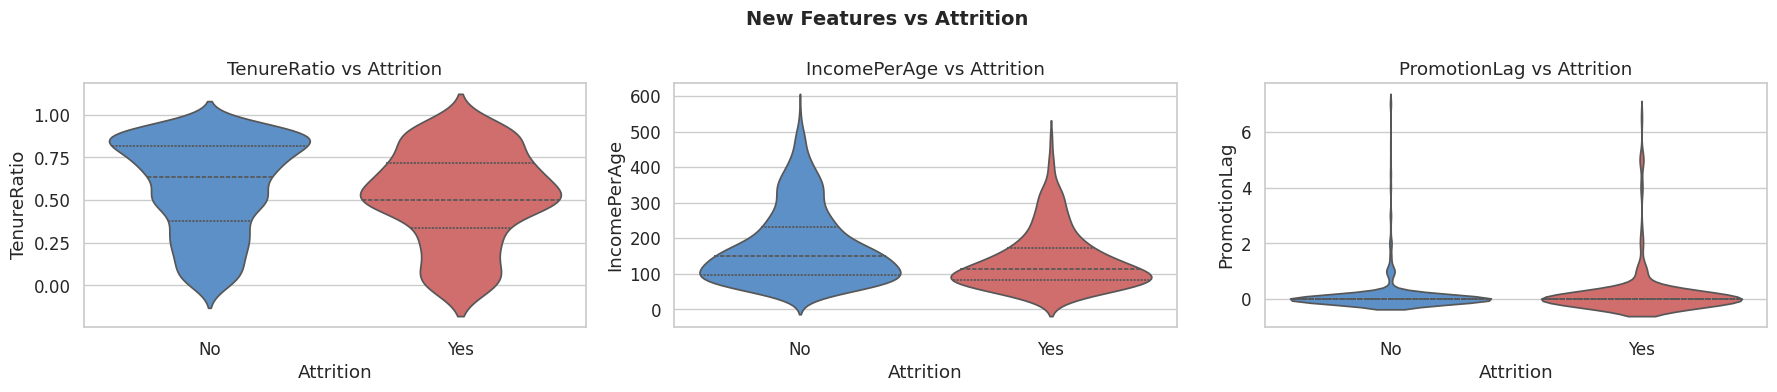

In [ ]:
# ══════════════════════════════════════════════════════════════════
# ██  SECTION 5 — FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────────
# [CELL 5-1]  Drop Unsuitable Features
# ─────────────────────────────────────────────────────────────────
print("╔══ 5.1  DROP UNSUITABLE FEATURES ════════════╗")

df_fe = df.copy()

reasons = {
    "MonthlyRate"       : "high corr with MonthlyIncome, less interpretable",
    "DailyRate"         : "high corr with MonthlyIncome, less interpretable",
    "HourlyRate"        : "high corr with MonthlyIncome, less interpretable",
    "PerformanceRating" : "only 2 unique values (3 & 4) — near-zero variance",
}
df_fe.drop(columns=list(reasons.keys()), inplace=True)

for col, reason in reasons.items():
    print(f"  ✂️  {col:<22} → {reason}")

print(f"\n  Shape after drop : {df_fe.shape}")


# ─────────────────────────────────────────────────────────────────
# [CELL 5-2]  Create New Features
# ─────────────────────────────────────────────────────────────────
print("╔══ 5.2  FEATURE CREATION ════════════════════╗")

# Fraction of career spent at current company (loyalty proxy)
df_fe["TenureRatio"] = (
    df_fe["YearsAtCompany"] / (df_fe["TotalWorkingYears"] + 1)
).round(4)

# Monthly income relative to age (career growth proxy)
df_fe["IncomePerAge"] = (
    df_fe["MonthlyIncome"] / df_fe["Age"]
).round(2)

# How far behind on promotions relative to time in current role
df_fe["PromotionLag"] = (
    df_fe["YearsSinceLastPromotion"] - df_fe["YearsInCurrentRole"]
).clip(lower=0)

new_feats = ["TenureRatio", "IncomePerAge", "PromotionLag"]
print(f"  Created : {new_feats}\n")
print(df_fe[new_feats].describe().round(3).to_string())

# Visualise new features vs Attrition
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col in zip(axes, new_feats):
    sns.violinplot(data=df_fe, x="Attrition", y=col,
                   order=["No", "Yes"],
                   palette={"No": ACCENT, "Yes": SOFT_RED},
                   inner="quartile", ax=ax)
    ax.set_title(f"{col} vs Attrition")
plt.suptitle("New Features vs Attrition", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()



//Skip this

In [ ]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1470 non-null   int64  
 1   Attrition                 1470 non-null   object 
 2   BusinessTravel            1470 non-null   object 
 3   Department                1470 non-null   object 
 4   DistanceFromHome          1470 non-null   int64  
 5   Education                 1470 non-null   int64  
 6   EducationField            1470 non-null   object 
 7   EnvironmentSatisfaction   1470 non-null   int64  
 8   Gender                    1470 non-null   object 
 9   JobInvolvement            1470 non-null   int64  
 10  JobLevel                  1470 non-null   int64  
 11  JobRole                   1470 non-null   object 
 12  JobSatisfaction           1470 non-null   int64  
 13  MaritalStatus             1470 non-null   object 
 14  MonthlyI

In [ ]:
df_fe


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureRatio,IncomePerAge,PromotionLag
0,41,Yes,Travel_Rarely,Sales,1,2,Life Sciences,2,Female,3,...,8.0,0.5,1,6,4.0,0.0,5.0,0.6667,146.17,0.0
1,49,No,Travel_Frequently,Research & Development,8,1,Life Sciences,3,Male,2,...,10.0,3.0,3,10,7.0,1.0,7.0,0.9091,104.69,0.0
2,37,Yes,Travel_Rarely,Research & Development,2,2,Other,4,Male,2,...,7.0,3.0,3,0,0.0,0.0,0.0,0.0000,56.49,0.0
3,33,No,Travel_Frequently,Research & Development,3,4,Life Sciences,4,Female,3,...,8.0,3.0,3,8,7.0,3.0,0.0,0.8889,88.15,0.0
4,27,No,Travel_Rarely,Research & Development,2,1,Medical,1,Male,3,...,6.0,3.0,3,2,2.0,2.0,2.0,0.2857,128.44,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,Research & Development,23,2,Medical,3,Male,4,...,17.0,3.0,3,5,2.0,0.0,3.0,0.2778,71.42,0.0
1466,39,No,Travel_Rarely,Research & Development,6,1,Medical,4,Male,2,...,9.0,4.5,3,7,7.0,1.0,7.0,0.7000,256.18,0.0
1467,27,No,Travel_Rarely,Research & Development,4,3,Life Sciences,2,Male,4,...,6.0,0.5,3,6,2.0,0.0,3.0,0.8571,227.48,0.0
1468,49,No,Travel_Frequently,Sales,2,3,Medical,4,Male,2,...,17.0,3.0,2,9,6.0,0.0,8.0,0.5000,110.00,0.0


In [ ]:
from sklearn.model_selection import train_test_split

# Splitting the full processed dataframe into Train and Test
df_train, df_test = train_test_split(df_fe, test_size=0.2, random_state=42, stratify=df_fe['Attrition'])

print("╔══ DATA SPLIT SUMMARY ══════════════════════╗")
print(f"  Total Rows    : {len(df_fe)}")
print(f"  Training Set  : {df_train.shape[0]} rows (df_train)")
print(f"  Testing Set   : {df_test.shape[0]} rows (df_test)")
print(f"  Columns       : {df_train.shape[1]}")
print("╚════════════════════════════════════════════╝")

display(df_train.head())

╔══ DATA SPLIT SUMMARY ══════════════════════╗
  Total Rows    : 1470
  Training Set  : 1176 rows (df_train)
  Testing Set   : 294 rows (df_test)
  Columns       : 30
╚════════════════════════════════════════════╝


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureRatio,IncomePerAge,PromotionLag
1194,47,No,Travel_Rarely,Sales,2,4,Life Sciences,2,Female,4,...,28.5,2.0,3,3,2.0,1.0,2.0,0.1017,339.83,0.0
128,22,No,Travel_Rarely,Research & Development,2,1,Technical Degree,3,Male,3,...,3.0,2.0,3,2,1.0,2.0,1.0,0.5000,114.68,1.0
810,46,No,Travel_Rarely,Sales,3,1,Marketing,1,Male,3,...,23.0,3.0,3,12,9.0,4.0,9.0,0.5000,379.67,0.0
478,25,No,Travel_Rarely,Sales,13,1,Medical,2,Male,3,...,7.0,1.0,3,7,4.0,0.0,6.0,0.8750,83.84,0.0
491,43,No,Travel_Frequently,Research & Development,9,5,Medical,4,Male,3,...,10.0,3.0,3,8,7.0,4.0,7.0,0.7273,132.07,0.0


check rate attrition df train

Attrition
No     986
Yes    190
Attrition
No     83.8 %
Yes    16.2 %


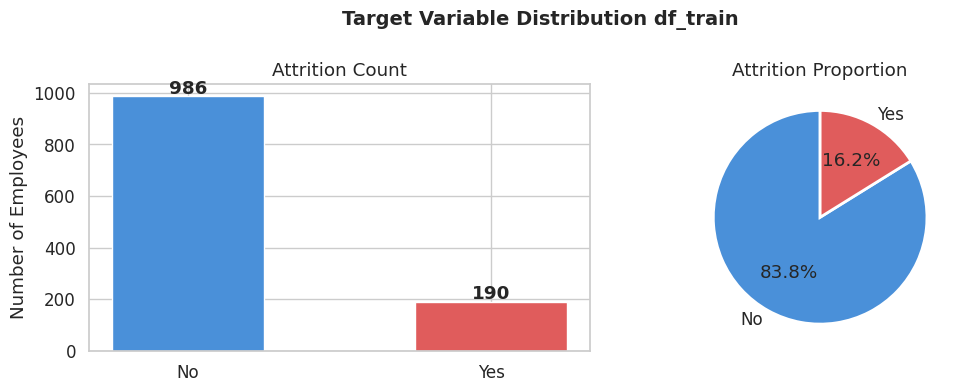

In [ ]:
att_counts = df_train["Attrition"].value_counts()
att_pct    = df_train["Attrition"].value_counts(normalize=True).mul(100).round(1)
print(att_counts.to_string())
print((att_pct.astype(str) + " %").to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Count bar
axes[0].bar(att_counts.index, att_counts.values,
            color=[COLORS[k] for k in att_counts.index],
            edgecolor="white", width=0.5)
for i, (k, v) in enumerate(att_counts.items()):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")
axes[0].set_title("Attrition Count")
axes[0].set_ylabel("Number of Employees")

# Pie
axes[1].pie(att_counts.values,
            labels=att_counts.index,
            colors=[COLORS[k] for k in att_counts.index],
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Attrition Proportion")

plt.suptitle("Target Variable Distribution df_train", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

check rate attrition df test

Attrition
No     247
Yes     47
Attrition
No     84.0 %
Yes    16.0 %


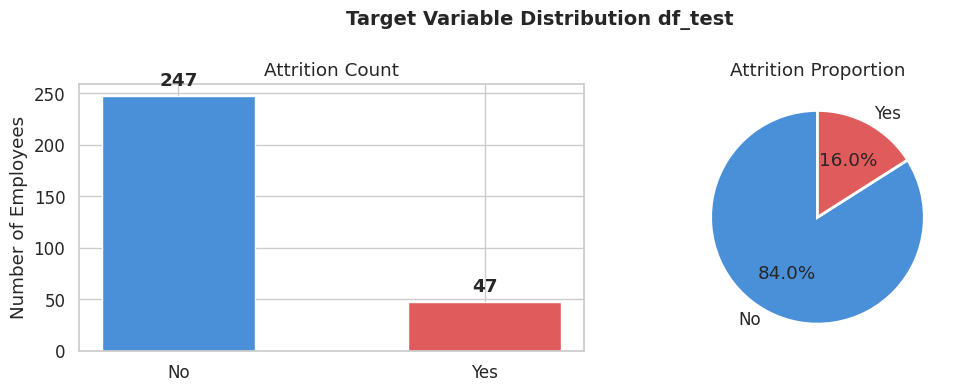

In [ ]:
att_counts = df_test["Attrition"].value_counts()
att_pct    = df_test["Attrition"].value_counts(normalize=True).mul(100).round(1)
print(att_counts.to_string())
print((att_pct.astype(str) + " %").to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Count bar
axes[0].bar(att_counts.index, att_counts.values,
            color=[COLORS[k] for k in att_counts.index],
            edgecolor="white", width=0.5)
for i, (k, v) in enumerate(att_counts.items()):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")
axes[0].set_title("Attrition Count")
axes[0].set_ylabel("Number of Employees")

# Pie
axes[1].pie(att_counts.values,
            labels=att_counts.index,
            colors=[COLORS[k] for k in att_counts.index],
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Attrition Proportion")

plt.suptitle("Target Variable Distribution df_test", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Oversampling for df_train

In [ ]:
df_train_syn = df_train.copy()

In [ ]:
df_train_syn

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureRatio,IncomePerAge,PromotionLag
1194,47,No,Travel_Rarely,Sales,2,4,Life Sciences,2,Female,4,...,28.5,2.0,3,3,2.0,1.0,2.0,0.1017,339.83,0.0
128,22,No,Travel_Rarely,Research & Development,2,1,Technical Degree,3,Male,3,...,3.0,2.0,3,2,1.0,2.0,1.0,0.5000,114.68,1.0
810,46,No,Travel_Rarely,Sales,3,1,Marketing,1,Male,3,...,23.0,3.0,3,12,9.0,4.0,9.0,0.5000,379.67,0.0
478,25,No,Travel_Rarely,Sales,13,1,Medical,2,Male,3,...,7.0,1.0,3,7,4.0,0.0,6.0,0.8750,83.84,0.0
491,43,No,Travel_Frequently,Research & Development,9,5,Medical,4,Male,3,...,10.0,3.0,3,8,7.0,4.0,7.0,0.7273,132.07,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213,23,Yes,Travel_Rarely,Sales,7,3,Life Sciences,3,Male,3,...,3.0,2.0,3,3,2.0,0.0,2.0,0.7500,98.91,0.0
963,38,No,Travel_Rarely,Sales,2,2,Life Sciences,2,Female,3,...,11.0,3.0,3,7,7.0,1.0,7.0,0.5833,181.39,0.0
734,22,No,Travel_Rarely,Research & Development,8,1,Life Sciences,2,Male,1,...,4.0,3.0,2,4,3.0,1.0,1.0,0.8000,111.41,0.0
1315,36,No,Travel_Rarely,Research & Development,2,4,Other,4,Female,3,...,15.0,2.0,3,1,0.0,0.0,0.0,0.0625,193.39,0.0


╔══ 5.5  CLASS IMBALANCE — SMOTE-NC ════════════════╗
  Label mapping : No → 0  |  Yes → 1
  Categorical (7) : ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
  Numerical   (22) : ['Age', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'TenureRatio', 'IncomePerAge', 'PromotionLag']

  Class 0 (No)  : 986
  Class 1 (Yes) : 190
  Minority ratio: 0.193

  ⚠️  Imbalanced — applying SMOTE-NC …


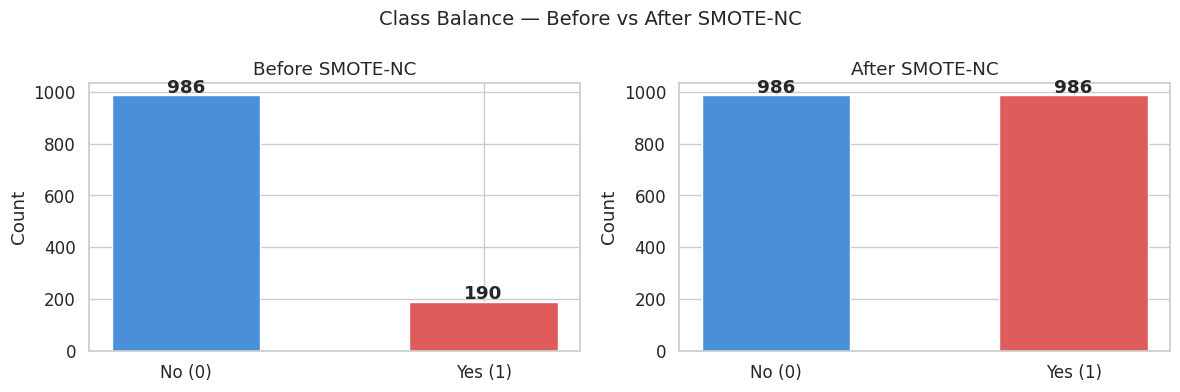


  ✅  Shape after SMOTE-NC + encoding : (1972, 30)
  ✅  Attrition dtype                 : int64


In [ ]:
print("╔══ 5.5  CLASS IMBALANCE — SMOTE-NC ════════════════╗")

from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import OrdinalEncoder

X_pre = df_train_syn.drop(columns=["Attrition"])
y_pre = df_train_syn["Attrition"]

# ── 1. Encode target BEFORE SMOTE-NC ──────────────────────────
y_pre_encoded = y_pre.map({"No": 0, "Yes": 1}).astype(int)
print(f"  Label mapping : No → 0  |  Yes → 1")

# ── 2. Identify column types (raw, un-encoded) ─────────────────
cat_cols = X_pre.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_pre.select_dtypes(include=["number"]).columns.tolist()
cat_indices = [X_pre.columns.get_loc(c) for c in cat_cols]

print(f"  Categorical ({len(cat_cols)}) : {cat_cols}")
print(f"  Numerical   ({len(num_cols)}) : {num_cols}")

# ── 3. Class distribution ──────────────────────────────────────
counts = y_pre_encoded.value_counts().sort_index()
ratio  = counts.min() / counts.max()
print(f"\n  Class 0 (No)  : {counts[0]}")
print(f"  Class 1 (Yes) : {counts[1]}")
print(f"  Minority ratio: {ratio:.3f}")

# ── 4. Visualise before ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(["No (0)", "Yes (1)"], [counts[0], counts[1]],
            color=[ACCENT, SOFT_RED], edgecolor="white", width=0.5)
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")
axes[0].set_title("Before SMOTE-NC")
axes[0].set_ylabel("Count")

if ratio < 0.4:
    print("\n  ⚠️  Imbalanced — applying SMOTE-NC …")

    # ── 5. Apply SMOTE-NC on RAW features + encoded y ─────────
    smote_nc = SMOTENC(categorical_features=cat_indices, random_state=42)
    X_res, y_res = smote_nc.fit_resample(X_pre, y_pre_encoded)

    X_res = pd.DataFrame(X_res, columns=X_pre.columns)
    y_res = pd.Series(y_res, name="Attrition").astype(int)

    # ── 6. Encode categoricals AFTER resampling ────────────────
    oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_res[cat_cols] = oe.fit_transform(X_res[cat_cols]).astype(int)
    X_res[num_cols] = X_res[num_cols].astype(float)

    # ── 7. Visualise after ─────────────────────────────────────
    new_counts = y_res.value_counts().sort_index()
    axes[1].bar(["No (0)", "Yes (1)"], [new_counts[0], new_counts[1]],
                color=[ACCENT, SOFT_RED], edgecolor="white", width=0.5)
    for i, v in enumerate([new_counts[0], new_counts[1]]):
        axes[1].text(i, v + 10, str(v), ha="center", fontweight="bold")
    axes[1].set_title("After SMOTE-NC")
    axes[1].set_ylabel("Count")
    plt.suptitle("Class Balance — Before vs After SMOTE-NC", fontsize=14)
    plt.tight_layout()
    plt.show()

    df_final = X_res.copy()
    df_final["Attrition"] = y_res.values
    print(f"\n  ✅  Shape after SMOTE-NC + encoding : {df_final.shape}")
    print(f"  ✅  Attrition dtype                 : {df_final['Attrition'].dtype}")

else:
    # Encode even when SMOTE not needed
    X_encoded = X_pre.copy()
    oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_encoded[cat_cols] = oe.fit_transform(X_encoded[cat_cols]).astype(int)

    axes[1].bar(["No (0)", "Yes (1)"], [counts[0], counts[1]],
                color=[ACCENT, SOFT_RED], edgecolor="white", width=0.5)
    axes[1].set_title("No SMOTE-NC Needed")
    plt.suptitle("Class Balance", fontsize=14)
    plt.tight_layout()
    plt.show()

    df_final = X_encoded.copy()
    df_final["Attrition"] = y_pre_encoded.values
    print("  ✅  Classes balanced — SMOTE-NC not applied.")
    print(f"  ✅  Attrition dtype : {df_final['Attrition'].dtype}")

In [ ]:
df_final


,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureRatio,IncomePerAge,PromotionLag,Attrition
0,47.0,2,2,2.0,4.0,1,2.0,0,4.0,4.0,...,2.000000,3.0,3.0,2.000000,1.000000,2.000000,0.101700,339.830000,0.0,0
1,22.0,2,1,2.0,1.0,5,3.0,1,3.0,1.0,...,2.000000,3.0,2.0,1.000000,2.000000,1.000000,0.500000,114.680000,1.0,0
2,46.0,2,2,3.0,1.0,2,1.0,1,3.0,4.0,...,3.000000,3.0,12.0,9.000000,4.000000,9.000000,0.500000,379.670000,0.0,0
3,25.0,2,2,13.0,1.0,3,2.0,1,3.0,1.0,...,1.000000,3.0,7.0,4.000000,0.000000,6.000000,0.875000,83.840000,0.0,0
4,43.0,1,1,9.0,5.0,3,4.0,1,3.0,2.0,...,3.000000,3.0,8.0,7.000000,4.000000,7.000000,0.727300,132.070000,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1967,38.0,2,2,11.0,2.0,2,1.0,1,1.0,2.0,...,2.000000,2.0,1.0,1.520188,1.520188,1.520188,0.200028,145.034876,0.0,1
1968,37.0,1,2,26.0,3.0,1,2.0,1,2.0,2.0,...,3.394253,2.0,5.0,3.442299,0.442299,1.884598,0.580362,184.680201,0.0,1
1969,33.0,2,1,6.0,3.0,1,1.0,0,3.0,1.0,...,1.279880,3.0,4.0,3.559760,1.688048,3.559760,0.659276,81.080494,0.0,1
1970,30.0,2,1,16.0,3.0,5,1.0,1,2.0,1.0,...,2.198143,3.0,2.0,2.000000,2.000000,0.641485,0.378606,77.174653,0.0,1


In [ ]:
df_final.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1972 entries, 0 to 1971
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1972 non-null   float64
 1   BusinessTravel            1972 non-null   int64  
 2   Department                1972 non-null   int64  
 3   DistanceFromHome          1972 non-null   float64
 4   Education                 1972 non-null   float64
 5   EducationField            1972 non-null   int64  
 6   EnvironmentSatisfaction   1972 non-null   float64
 7   Gender                    1972 non-null   int64  
 8   JobInvolvement            1972 non-null   float64
 9   JobLevel                  1972 non-null   float64
 10  JobRole                   1972 non-null   int64  
 11  JobSatisfaction           1972 non-null   float64
 12  MaritalStatus             1972 non-null   int64  
 13  MonthlyIncome             1972 non-null   float64
 14  NumCompa

In [ ]:
df_test

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureRatio,IncomePerAge,PromotionLag
1061,24,No,Non-Travel,Sales,13,2,Life Sciences,4,Female,3,...,1.0,2.0,3,1,0.0,0.0,0.0,0.5000,84.71,0.0
891,44,No,Travel_Rarely,Research & Development,2,1,Life Sciences,1,Female,4,...,10.0,4.5,3,10,5.0,7.0,7.0,0.9091,45.70,2.0
456,31,No,Travel_Rarely,Sales,7,3,Life Sciences,3,Male,2,...,10.0,3.0,2,5,4.0,0.0,1.0,0.4545,372.81,0.0
922,44,No,Travel_Rarely,Research & Development,4,2,Life Sciences,3,Male,4,...,26.0,4.0,2,18,9.0,7.5,13.0,0.6667,436.14,0.0
69,36,Yes,Travel_Rarely,Research & Development,9,3,Medical,4,Male,2,...,2.0,0.5,2,1,0.0,0.0,0.0,0.3333,94.11,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1269,43,No,Travel_Rarely,Human Resources,2,3,Life Sciences,2,Male,3,...,10.0,4.5,3,9,7.0,1.0,8.0,0.8182,82.30,0.0
1352,44,No,Travel_Rarely,Research & Development,1,4,Life Sciences,2,Male,4,...,10.0,4.5,3,2,0.0,2.0,2.0,0.1818,114.39,2.0
1236,36,Yes,Travel_Rarely,Sales,13,5,Marketing,2,Male,2,...,16.0,3.0,3,2,2.0,2.0,2.0,0.1176,170.39,0.0
1023,56,No,Travel_Rarely,Research & Development,1,2,Life Sciences,1,Female,3,...,5.0,3.0,4,3,2.0,1.0,0.0,0.5000,36.89,0.0


In [ ]:
# 1. Encode target in df_test (NO OVERSAMPLING)
df_test['Attrition'] = df_test['Attrition'].map({'No': 0, 'Yes': 1}).astype(int)

# 2. Identify categorical and numerical columns
cat_cols_test = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
num_cols_test = [c for c in df_test.columns if c not in cat_cols_test and c != 'Attrition']

# 3. Apply OrdinalEncoder (oe) fitted on training data
# We use .transform() to apply training logic to the test set
df_test[cat_cols_test] = oe.transform(df_test[cat_cols_test]).astype(int)

# 4. Ensure numeric columns are float for consistency
df_test[num_cols_test] = df_test[num_cols_test].astype(float)

print("✅ df_test encoded and formatted successfully (Original distribution preserved).")
display(df_test.head())

✅ df_test encoded and formatted successfully (Original distribution preserved).


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureRatio,IncomePerAge,PromotionLag
1061,24.0,0,0,2,13.0,2.0,1,4.0,0,3.0,...,1.0,2.0,3.0,1.0,0.0,0.0,0.0,0.5000,84.71,0.0
891,44.0,0,2,1,2.0,1.0,1,1.0,0,4.0,...,10.0,4.5,3.0,10.0,5.0,7.0,7.0,0.9091,45.70,2.0
456,31.0,0,2,2,7.0,3.0,1,3.0,1,2.0,...,10.0,3.0,2.0,5.0,4.0,0.0,1.0,0.4545,372.81,0.0
922,44.0,0,2,1,4.0,2.0,1,3.0,1,4.0,...,26.0,4.0,2.0,18.0,9.0,7.5,13.0,0.6667,436.14,0.0
69,36.0,1,2,1,9.0,3.0,3,4.0,1,2.0,...,2.0,0.5,2.0,1.0,0.0,0.0,0.0,0.3333,94.11,0.0


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 294 entries, 1061 to 285
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       294 non-null    float64
 1   Attrition                 294 non-null    int64  
 2   BusinessTravel            294 non-null    int64  
 3   Department                294 non-null    int64  
 4   DistanceFromHome          294 non-null    float64
 5   Education                 294 non-null    float64
 6   EducationField            294 non-null    int64  
 7   EnvironmentSatisfaction   294 non-null    float64
 8   Gender                    294 non-null    int64  
 9   JobInvolvement            294 non-null    float64
 10  JobLevel                  294 non-null    float64
 11  JobRole                   294 non-null    int64  
 12  JobSatisfaction           294 non-null    float64
 13  MaritalStatus             294 non-null    int64  
 14  MonthlyIncom

In [ ]:
from google.colab import files

# Export df_final (the resampled/full encoded dataset)
df_final.to_csv('df_final.csv', index=False)

# Export df_test (the 20% hold-out set)
df_test.to_csv('df_test.csv', index=False)

print("✅ CSV files generated: 'df_final.csv' and 'df_test.csv'")

# Trigger downloads
files.download('df_final.csv')
files.download('df_test.csv')

✅ CSV files generated: 'df_final.csv' and 'df_test.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_train_syns_ctgan = df_train.copy()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 30.8 MB/s eta 0:00:00
╔══ 5.6  CLASS IMBALANCE — CTGAN ════════════════╗
  Categorical columns for CTGAN: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

  Original Class 0 (No)  : 986
  Original Class 1 (Yes) : 190
  Generating 796 synthetic samples for minority class (Yes).

  Class distribution after CTGAN:
  Class 0 (No)  : 986
  Class 1 (Yes) : 986


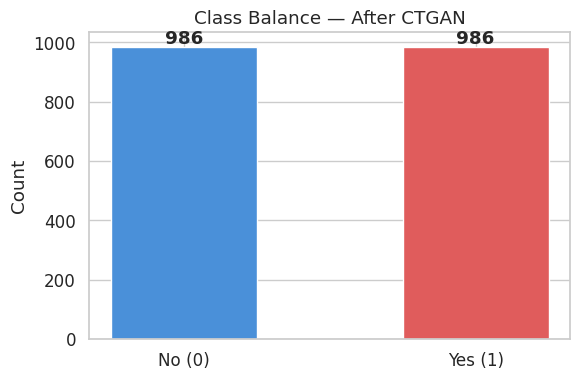


  ✅  Shape after CTGAN + encoding : (1972, 30)
  ✅  Attrition dtype              : int64


In [ ]:
import sys
!{sys.executable} -m pip install ctgan

from ctgan import CTGAN
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd
import matplotlib.pyplot as plt

print("╔══ 5.6  CLASS IMBALANCE — CTGAN ════════════════╗")

# Make a copy of the training data for CTGAN processing
df_ctgan_train = df_train_syns_ctgan.copy()

# 1. Separate features (X) and target (y)
X_ctgan = df_ctgan_train.drop(columns=["Attrition"])
y_ctgan = df_ctgan_train["Attrition"]

# Encode the target variable for CTGAN's internal use (0 and 1)
y_ctgan_encoded = y_ctgan.map({"No": 0, "Yes": 1}).astype(int)

# Identify categorical columns
cat_cols_ctgan = X_ctgan.select_dtypes(include=["object"]).columns.tolist()
print(f"  Categorical columns for CTGAN: {cat_cols_ctgan}")

# 2. Initialize and fit CTGAN
# CTGAN will learn the data distribution, including categorical dependencies.
ctgan = CTGAN(epochs=100, verbose=False) # epochs can be adjusted
ctgan.fit(X_ctgan, cat_cols_ctgan)

# 3. Generate synthetic samples
# Determine how many minority samples to generate to balance with the majority class
counts_ctgan = y_ctgan_encoded.value_counts().sort_index()
minority_class_count = counts_ctgan[1] # 'Yes' class (encoded as 1)
majority_class_count = counts_ctgan[0] # 'No' class (encoded as 0)
num_synthetic_samples = majority_class_count - minority_class_count

print(f"\n  Original Class 0 (No)  : {majority_class_count}")
print(f"  Original Class 1 (Yes) : {minority_class_count}")
print(f"  Generating {num_synthetic_samples} synthetic samples for minority class (Yes).")

synthetic_data = ctgan.sample(num_synthetic_samples)

# 4. Combine original and synthetic data
# Add the encoded 'Attrition' column back to X_ctgan for concatenation
X_ctgan_with_target = X_ctgan.copy()
X_ctgan_with_target['Attrition'] = y_ctgan_encoded

# Assign 'Attrition' label 1 (Yes) to all synthetic samples
synthetic_data['Attrition'] = 1

# Ensure columns are in the same order before concatenation
synthetic_data = synthetic_data[X_ctgan_with_target.columns]

df_ctgan_balanced = pd.concat([X_ctgan_with_target, synthetic_data], ignore_index=True)

# 5. Encode categorical features and ensure all numeric columns are float
# Re-initialize and fit OrdinalEncoder on the combined (original + synthetic) data
oe_ctgan = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df_ctgan_balanced[cat_cols_ctgan] = oe_ctgan.fit_transform(df_ctgan_balanced[cat_cols_ctgan]).astype(int)

# Ensure numeric columns are float for consistency
num_cols_ctgan = [col for col in df_ctgan_balanced.columns if col not in cat_cols_ctgan and col != 'Attrition']
df_ctgan_balanced[num_cols_ctgan] = df_ctgan_balanced[num_cols_ctgan].astype(float)


# Display class distribution after CTGAN
final_counts_ctgan = df_ctgan_balanced["Attrition"].value_counts().sort_index()
print("\n  Class distribution after CTGAN:")
print(f"  Class 0 (No)  : {final_counts_ctgan[0]}")
print(f"  Class 1 (Yes) : {final_counts_ctgan[1]}")

# Visualise after CTGAN
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["No (0)", "Yes (1)"], [final_counts_ctgan[0], final_counts_ctgan[1]],
       color=[ACCENT, SOFT_RED], edgecolor="white", width=0.5)
for i, v in enumerate([final_counts_ctgan[0], final_counts_ctgan[1]]):
    ax.text(i, v + 10, str(v), ha="center", fontweight="bold")
ax.set_title("Class Balance — After CTGAN")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

df_train_ctgan_final = df_ctgan_balanced.copy()
print(f"\n  ✅  Shape after CTGAN + encoding : {df_train_ctgan_final.shape}")
print(f"  ✅  Attrition dtype              : {df_train_ctgan_final['Attrition'].dtype}")

In [ ]:
df_train_ctgan_final.describe()

,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureRatio,IncomePerAge,PromotionLag,Attrition
count,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000,...,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000
mean,37.947262,1.593813,1.253043,9.375254,2.971602,2.282454,2.800710,0.593306,2.754057,1.952840,...,2.664486,2.740365,6.154158,3.909366,2.289132,3.748149,0.632713,168.071306,0.222088,0.500000
std,10.099518,0.677853,0.555737,8.049892,1.022430,1.367090,1.038742,0.491341,0.639364,1.097623,...,0.973431,0.697559,4.960889,3.617219,2.701411,3.505598,0.263639,105.036063,0.802150,0.500127
min,11.000000,0.000000,0.000000,-2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,...,-0.191700,0.000000,-2.000000,-1.689730,-0.392027,-1.440469,-0.020940,1.660009,-1.667542,0.000000
25%,31.000000,1.000000,1.000000,2.000000,2.000000,1.000000,2.000000,0.000000,2.000000,1.000000,...,2.000000,2.000000,2.000000,1.476587,0.037383,1.000000,0.491719,90.123424,0.000000,0.000000
50%,37.000000,2.000000,1.000000,7.000000,3.000000,2.000000,3.000000,1.000000,3.000000,2.000000,...,2.904651,3.000000,5.000000,2.306508,1.000000,2.434873,0.666700,135.825000,0.000000,0.500000
75%,45.000000,2.000000,2.000000,15.000000,4.000000,3.000000,4.000000,1.000000,3.000000,2.000000,...,3.000000,3.000000,9.000000,7.000000,3.878498,7.000000,0.856490,220.273633,0.014054,1.000000
max,69.000000,2.000000,2.000000,36.000000,6.000000,5.000000,4.000000,1.000000,4.000000,6.000000,...,5.296453,4.000000,22.000000,20.115797,9.397523,15.601876,1.098109,563.587934,9.762099,1.000000


In [ ]:
from google.colab import files

# Export df_final (the resampled/full encoded dataset)
df_final.to_csv('df_final.csv', index=False)

# Export df_test (the 20% hold-out set)
df_test.to_csv('df_test.csv', index=False)

print("✅ CSV files generated: 'df_final.csv' and 'df_test.csv'")

# Trigger downloads
files.download('df_final.csv')
files.download('df_test.csv')

In [ ]:
df_final.describe()

,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureRatio,IncomePerAge,PromotionLag,Attrition
count,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000,...,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000,1972.000000
mean,35.086714,1.686105,1.289047,9.590264,2.770791,2.116126,2.435091,0.677485,2.521805,1.883874,...,2.626906,2.582657,5.636410,3.634872,1.794927,3.596798,0.549503,158.489807,0.212429,0.500000
std,9.163661,0.587671,0.524026,7.621465,0.967351,1.281014,1.074753,0.467557,0.749789,1.046462,...,0.947703,0.740756,4.698106,3.282321,2.295207,3.286318,0.254030,92.977950,0.801549,0.500127
min,18.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,...,0.500000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,36.030000,0.000000,0.000000
25%,29.000000,2.000000,1.000000,3.000000,2.000000,1.000000,1.000000,0.000000,2.000000,1.000000,...,2.000000,2.000000,2.000000,1.061454,0.000000,1.000000,0.375000,88.507642,0.000000,0.000000
50%,34.000000,2.000000,1.000000,8.000000,3.000000,2.000000,2.000000,1.000000,3.000000,2.000000,...,2.571877,3.000000,5.000000,2.218770,1.000000,2.389197,0.560423,130.440000,0.000000,0.500000
75%,41.000000,2.000000,2.000000,14.000000,3.000000,3.000000,3.000000,1.000000,3.000000,2.000000,...,3.000000,3.000000,8.000000,6.643559,2.286334,6.773760,0.764700,203.167907,0.000000,1.000000
max,60.000000,2.000000,2.000000,29.000000,5.000000,5.000000,4.000000,1.000000,4.000000,5.000000,...,4.500000,4.000000,18.000000,14.500000,7.500000,14.500000,0.947400,556.000000,7.000000,1.000000


In [ ]:
from google.colab import files

# Export df_final (the resampled/full encoded dataset)
df_train_ctgan_final.to_csv('df_final_ctgan.csv', index=False)

# Trigger downloads
files.download('df_final_ctgan.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
X_ctgan.describe()

,Age,DistanceFromHome,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureRatio,IncomePerAge,PromotionLag
count,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,...,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000
mean,36.998299,9.357993,2.906463,2.716837,2.737245,2.076531,2.719388,6544.024660,2.677721,15.239796,...,11.187925,2.679422,2.757653,6.664116,4.213435,1.920493,4.181973,0.573471,171.653214,0.177721
std,9.178142,8.179803,1.027996,1.088707,0.703673,1.091987,1.110644,4653.743955,2.448422,3.679081,...,7.328085,1.015054,0.718113,4.973489,3.513309,2.480703,3.518288,0.273286,100.145145,0.773693
min,18.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1009.000000,0.000000,11.000000,...,0.000000,0.500000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,36.030000,0.000000
25%,30.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,2948.000000,1.000000,12.000000,...,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,0.375000,94.955000,0.000000
50%,36.000000,7.000000,3.000000,3.000000,3.000000,2.000000,3.000000,5004.500000,2.000000,14.000000,...,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,0.610200,142.620000,0.000000
75%,43.000000,14.000000,4.000000,4.000000,3.000000,3.000000,4.000000,8420.500000,4.000000,18.000000,...,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,0.818200,225.390000,0.000000
max,60.000000,29.000000,5.000000,4.000000,4.000000,5.000000,4.000000,19973.000000,8.500000,25.000000,...,28.500000,4.500000,4.000000,18.000000,14.500000,7.500000,14.500000,0.947400,556.000000,7.000000


In [ ]:
df_ctgan_raw = X_ctgan.copy()
df_ctgan_raw["Atrribution"] = y_ctgan_encoded


In [ ]:
from google.colab import files

# Export df_final (the resampled/full encoded dataset)
df_ctgan_raw.to_csv('df_final_ctgan_raw.csv', index=False)

# Trigger downloads
files.download('df_final_ctgan_raw.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_ctgan_raw

,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureRatio,IncomePerAge,PromotionLag,Attrition
1194,47.0,2,2,2.0,4.0,1,2.0,0,4.0,4.0,...,2.0,3.0,3.0,2.0,1.0,2.0,0.1017,339.83,0.0,0
128,22.0,2,1,2.0,1.0,5,3.0,1,3.0,1.0,...,2.0,3.0,2.0,1.0,2.0,1.0,0.5000,114.68,1.0,0
810,46.0,2,2,3.0,1.0,2,1.0,1,3.0,4.0,...,3.0,3.0,12.0,9.0,4.0,9.0,0.5000,379.67,0.0,0
478,25.0,2,2,13.0,1.0,3,2.0,1,3.0,1.0,...,1.0,3.0,7.0,4.0,0.0,6.0,0.8750,83.84,0.0,0
491,43.0,1,1,9.0,5.0,3,4.0,1,3.0,2.0,...,3.0,3.0,8.0,7.0,4.0,7.0,0.7273,132.07,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213,23.0,2,2,7.0,3.0,1,3.0,1,3.0,1.0,...,2.0,3.0,3.0,2.0,0.0,2.0,0.7500,98.91,0.0,1
963,38.0,2,2,2.0,2.0,1,2.0,0,3.0,2.0,...,3.0,3.0,7.0,7.0,1.0,7.0,0.5833,181.39,0.0,0
734,22.0,2,1,8.0,1.0,1,2.0,1,1.0,1.0,...,3.0,2.0,4.0,3.0,1.0,1.0,0.8000,111.41,0.0,0
1315,36.0,2,1,2.0,4.0,4,4.0,0,3.0,2.0,...,2.0,3.0,1.0,0.0,0.0,0.0,0.0625,193.39,0.0,0


In [ ]:
# Rename misspelled column to match expected target name
df_ctgan_raw.rename(columns={'Atrribution': 'Attrition'}, inplace=True)

print("✅ Column 'Atrribution' renamed to 'Attrition' in df_ctgan_raw.")
print(f"Current columns: {df_ctgan_raw.columns.tolist()}")

✅ Column 'Atrribution' renamed to 'Attrition' in df_ctgan_raw.
Current columns: ['Age', 'BusinessTravel', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'TenureRatio', 'IncomePerAge', 'PromotionLag', 'Attrition']


In [ ]:
# 1. Encode target in df_test (NO OVERSAMPLING)
#f_ctgan_raw['Attrition'] = df_ctgan_raw['Attrition'].map({'No': 0, 'Yes': 1}).astype(int)

# 2. Identify categorical and numerical columns
cat_cols_test = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
num_cols_test = [c for c in df_ctgan_raw.columns if c not in cat_cols_test and c != 'Attrition']

# 3. Apply OrdinalEncoder (oe) fitted on training data
# We use .transform() to apply training logic to the test set
df_ctgan_raw[cat_cols_test] = oe.transform(df_ctgan_raw[cat_cols_test]).astype(int)

# 4. Ensure numeric columns are float for consistency
df_ctgan_raw[num_cols_test] = df_ctgan_raw[num_cols_test].astype(float)

print("✅ df_test encoded and formatted successfully (Original distribution preserved).")
display(df_ctgan_raw.head())

✅ df_test encoded and formatted successfully (Original distribution preserved).


,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureRatio,IncomePerAge,PromotionLag,Attrition
1194,47.0,2,2,2.0,4.0,1,2.0,0,4.0,4.0,...,2.0,3.0,3.0,2.0,1.0,2.0,0.1017,339.83,0.0,0
128,22.0,2,1,2.0,1.0,5,3.0,1,3.0,1.0,...,2.0,3.0,2.0,1.0,2.0,1.0,0.5000,114.68,1.0,0
810,46.0,2,2,3.0,1.0,2,1.0,1,3.0,4.0,...,3.0,3.0,12.0,9.0,4.0,9.0,0.5000,379.67,0.0,0
478,25.0,2,2,13.0,1.0,3,2.0,1,3.0,1.0,...,1.0,3.0,7.0,4.0,0.0,6.0,0.8750,83.84,0.0,0
491,43.0,1,1,9.0,5.0,3,4.0,1,3.0,2.0,...,3.0,3.0,8.0,7.0,4.0,7.0,0.7273,132.07,0.0,0


In [ ]:
print("╔══ DATASET VERIFICATION ══════════════════════╗")

def summarize_df(name, target_df):
    print(f"\n--- Dataset: {name} ---")
    print(f"  Shape: {target_df.shape}")
    print("  Class Distribution (Attrition):")
    counts = target_df['Attrition'].value_counts().sort_index()
    for cls, count in counts.items():
        print(f"    Class {cls}: {count} rows")
    display(target_df.head())

summarize_df("df_ctgan_raw (Original Training - Encoded)", df_ctgan_raw)
summarize_df("df_final (SMOTE-NC Balanced - Encoded)", df_final)

print("\n--- Dtype Check (Attrition) ---")
print(f"  df_ctgan_raw Attrition dtype: {df_ctgan_raw['Attrition'].dtype}")
print(f"  df_final Attrition dtype:     {df_final['Attrition'].dtype}")

╔══ DATASET VERIFICATION ══════════════════════╗

--- Dataset: df_ctgan_raw (Original Training - Encoded) ---
  Shape: (1176, 30)
  Class Distribution (Attrition):
    Class 0: 986 rows
    Class 1: 190 rows


,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureRatio,IncomePerAge,PromotionLag,Attrition
1194,47.0,2,2,2.0,4.0,1,2.0,0,4.0,4.0,...,2.0,3.0,3.0,2.0,1.0,2.0,0.1017,339.83,0.0,0
128,22.0,2,1,2.0,1.0,5,3.0,1,3.0,1.0,...,2.0,3.0,2.0,1.0,2.0,1.0,0.5000,114.68,1.0,0
810,46.0,2,2,3.0,1.0,2,1.0,1,3.0,4.0,...,3.0,3.0,12.0,9.0,4.0,9.0,0.5000,379.67,0.0,0
478,25.0,2,2,13.0,1.0,3,2.0,1,3.0,1.0,...,1.0,3.0,7.0,4.0,0.0,6.0,0.8750,83.84,0.0,0
491,43.0,1,1,9.0,5.0,3,4.0,1,3.0,2.0,...,3.0,3.0,8.0,7.0,4.0,7.0,0.7273,132.07,0.0,0



--- Dataset: df_final (SMOTE-NC Balanced - Encoded) ---
  Shape: (1972, 30)
  Class Distribution (Attrition):
    Class 0: 986 rows
    Class 1: 986 rows


,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureRatio,IncomePerAge,PromotionLag,Attrition
0,47.0,2,2,2.0,4.0,1,2.0,0,4.0,4.0,...,2.0,3.0,3.0,2.0,1.0,2.0,0.1017,339.83,0.0,0
1,22.0,2,1,2.0,1.0,5,3.0,1,3.0,1.0,...,2.0,3.0,2.0,1.0,2.0,1.0,0.5000,114.68,1.0,0
2,46.0,2,2,3.0,1.0,2,1.0,1,3.0,4.0,...,3.0,3.0,12.0,9.0,4.0,9.0,0.5000,379.67,0.0,0
3,25.0,2,2,13.0,1.0,3,2.0,1,3.0,1.0,...,1.0,3.0,7.0,4.0,0.0,6.0,0.8750,83.84,0.0,0
4,43.0,1,1,9.0,5.0,3,4.0,1,3.0,2.0,...,3.0,3.0,8.0,7.0,4.0,7.0,0.7273,132.07,0.0,0



--- Dtype Check (Attrition) ---
  df_ctgan_raw Attrition dtype: int64
  df_final Attrition dtype:     int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, roc_auc_score

def validate_strategy(train_name, df_train_set, df_test_set):
    print(f"\n{'='*60}\nSTRATEGY: {train_name}\n{'='*60}")

    # Prepare Training Data
    X_train = df_train_set.drop(columns=['Attrition'])
    y_train = df_train_set['Attrition']

    # Prepare Testing Data
    X_test = df_test_set.drop(columns=['Attrition'])
    y_test = df_test_set['Attrition']

    model = RandomForestClassifier(random_state=42, n_jobs=-1)

    # 1. Internal Cross-Validation (Consistency Check)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = cross_validate(model, X_train, y_train, cv=skf, scoring='f1')
    print(f"[CV] Internal Mean F1-Score: {cv_results['test_score'].mean():.4f}")

    # 2. Train on full training set and Validate on df_test
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n[TEST SET EVALUATION vs Unseen df_test]")
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

# Execute Validation for both processed sets
validate_strategy("df_ctgan_raw (Encoded Original)", df_ctgan_raw, df_test)
validate_strategy("df_final (SMOTE-NC Balanced)", df_final, df_test)


STRATEGY: df_ctgan_raw (Encoded Original)
[CV] Internal Mean F1-Score: 0.3363

[TEST SET EVALUATION vs Unseen df_test]
ROC-AUC Score: 0.7739

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.43      0.13      0.20        47

    accuracy                           0.83       294
   macro avg       0.64      0.55      0.55       294
weighted avg       0.79      0.83      0.79       294


STRATEGY: df_final (SMOTE-NC Balanced)
[CV] Internal Mean F1-Score: 0.9274

[TEST SET EVALUATION vs Unseen df_test]
ROC-AUC Score: 0.7869

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.94      0.90       247
           1       0.44      0.26      0.32        47

    accuracy                           0.83       294
   macro avg       0.66      0.60      0.61       294
weighted avg       0.80      0.83      0.81       294

